In [1]:
import pickle

with open("/kaggle/input/datasets/tsyaidfarhan/cq500-preprocessed-cache/cq500_splits.pkl", "rb") as f:
    splits = pickle.load(f)

print("Splits loaded successfully.")


Splits loaded successfully.


In [2]:
import os
import pickle
import math
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
import timm
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [3]:
# =====================
# Reproducibility
# =====================
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# =====================
# Paths & Config
# =====================
DATA_ROOT = "/kaggle/input/datasets/tsyaidfarhan/cq500-preprocessed-cache"
CACHE_ROOT = DATA_ROOT + "/cache/cache"
SPLITS_PATH = DATA_ROOT + "/cq500_splits.pkl"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================
# EXPERIMENT — Change this manually to the subtype you want
# =====================
EXPERIMENT_NAME = "any_ich"   # <-- CHANGE THIS to: "any_ich", "iph", "sdh", "sah", "edh", "ivh"

# =====================
# BACKBONES — Compare all backbones on the chosen experiment
# =====================
BACKBONE_NAMES = ["convnext_tiny", "resnet50", "efficientnet_b0"]

# Hyperparameters
EPOCHS = 40
BATCH_SIZE = 32
LEARNING_RATE = 3e-5          # lower LR for pretrained backbone
WEIGHT_DECAY = 5e-2           # stronger regularization
GRAD_ACCUM_STEPS = 2          # effective batch size = 32 * 2 = 64
PATIENCE = 10

print("Using device:", DEVICE)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Backbones to compare: {BACKBONE_NAMES}")

Using device: cuda
Experiment: any_ich
Backbones to compare: ['convnext_tiny', 'resnet50', 'efficientnet_b0']


In [4]:
import os

print("Example folder:", os.listdir(CACHE_ROOT)[:5])


Example folder: ['CQ500CT102', 'CQ500CT136', 'CQ500CT204', 'CQ500CT245', 'CQ500CT338']


In [5]:
print("CACHE_ROOT:", CACHE_ROOT)
print("Example study:", splits["any_ich"]["train"].iloc[0]["study_id"])

import os

test_study = splits["any_ich"]["train"].iloc[0]["study_id"]
test_path = os.path.join(CACHE_ROOT, test_study)

print("Study exists?", os.path.exists(test_path))
print("Files inside:", os.listdir(test_path)[:5] if os.path.exists(test_path) else "Not found")


CACHE_ROOT: /kaggle/input/datasets/tsyaidfarhan/cq500-preprocessed-cache/cache/cache
Example study: CQ500CT201
Study exists? True
Files inside: ['422.npy', '331.npy', '280.npy', '100.npy', '193.npy']


In [6]:
for exp_name, split_data in splits.items():
    
    print("\n", exp_name.upper())
    
    for subset in ["train","val","test"]:
        df_subset = split_data[subset]
        pos = df_subset["label"].sum()
        total = len(df_subset)
        print(f"{subset}: Positif {pos}/{total}")



 ANY_ICH
train: Positif 134/331
val: Positif 29/71
test: Positif 28/71

 IPH
train: Positif 90/287
val: Positif 20/62
test: Positif 19/62

 SDH
train: Positif 34/231
val: Positif 8/50
test: Positif 7/50

 SAH
train: Positif 40/237
val: Positif 9/51
test: Positif 8/51


In [7]:
from scipy.ndimage import rotate, affine_transform, gaussian_filter, map_coordinates

class AugmentationPipeline:
    """Enhanced augmentation pipeline for medical imaging."""
    
    def __init__(self, mode="train"):
        self.mode = mode
        
        # Probability control — slightly more aggressive for medical images
        self.p_flip = 0.5
        self.p_rotation = 0.7
        self.p_shift = 0.4
        self.p_noise = 0.3
        self.p_brightness = 0.3
        self.p_intensity = 0.4
        self.p_contrast = 0.4
        self.p_elastic = 0.2       # NEW: elastic deformation
        self.p_cutout = 0.3        # NEW: random erasing / cutout
    
    # -------------------------
    # Geometric Transformations
    # -------------------------
    
    def horizontal_flip(self, image):
        return np.flip(image, axis=1).copy()
    
    def random_rotation(self, image):
        angle = random.uniform(-20, 20)
        return rotate(image, angle, reshape=False, order=1, mode="nearest")
    
    def random_shift(self, image, max_shift_ratio=0.08):
        shift_x = image.shape[0] * max_shift_ratio * random.uniform(-1, 1)
        shift_y = image.shape[1] * max_shift_ratio * random.uniform(-1, 1)
        matrix = np.array([[1, 0], [0, 1]])
        offset = [-shift_x, -shift_y]
        return affine_transform(image, matrix, offset=offset, order=1, mode="nearest")
    
    def elastic_deformation(self, image, alpha=15, sigma=3):
        """Elastic deformation — effective for CT scans to simulate tissue variation."""
        shape = image.shape
        dx = gaussian_filter(np.random.randn(*shape) * alpha, sigma)
        dy = gaussian_filter(np.random.randn(*shape) * alpha, sigma)
        x, y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
        indices = [np.clip(y + dy, 0, shape[0] - 1), np.clip(x + dx, 0, shape[1] - 1)]
        return map_coordinates(image, indices, order=1, mode="nearest").reshape(shape)
    
    # -------------------------
    # Intensity Transformations
    # -------------------------
    
    def gaussian_noise(self, image):
        std = random.uniform(0.005, 0.02)
        noise = np.random.normal(0, std, image.shape)
        return np.clip(image + noise, 0, 1)
    
    def brightness(self, image):
        factor = random.uniform(0.85, 1.15)
        return np.clip(image * factor, 0, 1)
    
    def random_intensity(self, image):
        scale = random.uniform(0.85, 1.15)
        shift = random.uniform(-0.05, 0.05)
        return np.clip(image * scale + shift, 0, 1)
    
    def contrast(self, image):
        mean = np.mean(image)
        factor = random.uniform(0.75, 1.25)
        return np.clip((image - mean) * factor + mean, 0, 1)
    
    def cutout(self, image, max_holes=2, max_size=0.15):
        """Random rectangular cutout — forces model to use global context."""
        h, w = image.shape
        img = image.copy()
        n_holes = random.randint(1, max_holes)
        for _ in range(n_holes):
            sz_h = int(h * random.uniform(0.05, max_size))
            sz_w = int(w * random.uniform(0.05, max_size))
            y = random.randint(0, h - sz_h)
            x = random.randint(0, w - sz_w)
            img[y:y+sz_h, x:x+sz_w] = 0.0
        return img
    
    # -------------------------
    # Main Pipeline
    # -------------------------
    
    def apply(self, image):
        if self.mode != "train":
            return image.astype(np.float32)
        
        # GEOMETRIC
        if random.random() < self.p_flip:
            image = self.horizontal_flip(image)
        if random.random() < self.p_rotation:
            image = self.random_rotation(image)
        if random.random() < self.p_shift:
            image = self.random_shift(image)
        if random.random() < self.p_elastic:
            image = self.elastic_deformation(image)
        
        # INTENSITY
        if random.random() < self.p_contrast:
            image = self.contrast(image)
        if random.random() < self.p_intensity:
            image = self.random_intensity(image)
        if random.random() < self.p_brightness:
            image = self.brightness(image)
        
        # NOISE + CUTOUT last
        if random.random() < self.p_noise:
            image = self.gaussian_noise(image)
        if random.random() < self.p_cutout:
            image = self.cutout(image)
        
        return image.astype(np.float32)

In [8]:
def visualize_augmentation_safe(dataset_df, processor, preprocess,
                                study_idx=0, slice_idx=0, n_aug=6):
    
    import matplotlib.pyplot as plt
    
    row = dataset_df.iloc[study_idx]
    slice_idx = min(slice_idx, len(row["dicom_files"]) - 1)
    dicom_path = row["dicom_files"][slice_idx]
    
    raw = processor.read_hu(dicom_path)
    windowed = processor.brain_window(raw)
    resized = preprocess.resize(windowed)
    
    augmenter = AugmentationPipeline()
    
    total_images = n_aug + 1  # +1 untuk original
    
    cols = 4
    rows = int(np.ceil(total_images / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
    axes = axes.flatten()
    
    # Original
    axes[0].imshow(resized, cmap="gray")
    axes[0].set_title("Preprocessed")
    axes[0].axis("off")
    
    # Augmented
    for i in range(n_aug):
        aug_img = augmenter.apply(resized.copy())
        
        axes[i+1].imshow(aug_img, cmap="gray")
        axes[i+1].set_title(f"Aug {i+1}")
        axes[i+1].axis("off")
    
    # Hide empty plots
    for j in range(total_images, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()


In [9]:
# ImageNet normalization stats (critical for pretrained backbones)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class CachedSliceDataset(Dataset):

    def __init__(self, df, cache_root, augment=False, normalize=True):
        self.samples = []
        self.cache_root = cache_root
        self.augment = augment
        self.normalize = normalize
        self.augmenter = AugmentationPipeline(mode="train" if augment else "val")

        for _, row in df.iterrows():
            study_id = row["study_id"]
            label = row["label"]

            study_dir = os.path.join(cache_root, study_id)
            if not os.path.exists(study_dir):
                continue

            for f in sorted(os.listdir(study_dir)):
                if f.endswith(".npy"):
                    self.samples.append(
                        (os.path.join(study_dir, f), label, study_id)
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label, study_id = self.samples[idx]

        img = np.load(path).astype(np.float32)

        if self.augment:
            img = self.augmenter.apply(img)

        # Stack to 3-channel
        img = torch.tensor(img, dtype=torch.float32)
        img = torch.stack([img, img, img])  # (3, H, W)

        # ImageNet normalization for pretrained weights
        if self.normalize:
            img = (img - IMAGENET_MEAN) / IMAGENET_STD

        label = torch.tensor(label, dtype=torch.float32)

        return img, label, study_id

In [10]:
import torchvision.models as models

class GeM(nn.Module):
    """Generalized Mean Pooling — better than AvgPool for classification."""
    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        return F.adaptive_avg_pool2d(
            x.clamp(min=self.eps).pow(self.p), 1
        ).pow(1.0 / self.p)


class ICHModel(nn.Module):
    
    def __init__(self, backbone_name="convnext_tiny", dropout=0.4):
        super().__init__()
        self.backbone_name = backbone_name
        
        if backbone_name == "convnext_tiny":
            backbone = models.convnext_tiny(weights="IMAGENET1K_V1")
            in_features = backbone.classifier[2].in_features
            backbone.classifier = nn.Identity()
            
        elif backbone_name == "resnet50":
            backbone = models.resnet50(weights="IMAGENET1K_V1")
            in_features = backbone.fc.in_features
            backbone.fc = nn.Identity()
            
        elif backbone_name == "efficientnet_b0":
            backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
            in_features = backbone.classifier[1].in_features
            backbone.classifier = nn.Identity()
        
        else:
            raise ValueError(f"Backbone not recognized: {backbone_name}")
        
        self.backbone = backbone
        
        # Improved classification head with GeM pooling
        self.pool = GeM(p=3.0)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.GELU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1)
        )
    
    def forward(self, x):
        features = self.backbone(x)
        
        # ConvNeXt with Identity classifier outputs (B, features) directly
        # We need to handle both spatial and flat outputs
        if features.dim() == 4:
            features = self.pool(features)
        elif features.dim() == 2:
            features = features.unsqueeze(-1).unsqueeze(-1)
            features = self.pool(features)
        
        return self.head(features)
    
    def get_optimizer_groups(self, lr=3e-5, wd=5e-2, lr_decay=0.8):
        """Layer-wise LR decay — lower LR for early layers, higher for head."""
        backbone_params = list(self.backbone.parameters())
        head_params = list(self.pool.parameters()) + list(self.head.parameters())
        
        n_layers = len(backbone_params)
        groups = []
        
        for i, p in enumerate(backbone_params):
            layer_lr = lr * (lr_decay ** (n_layers - i - 1))
            groups.append({"params": [p], "lr": layer_lr, "weight_decay": wd})
        
        groups.append({
            "params": head_params,
            "lr": lr * 5,  # head learns faster
            "weight_decay": wd
        })
        
        return groups

print("ICHModel defined with GeM pooling + multi-layer head.")

ICHModel defined with GeM pooling + multi-layer head.


In [11]:
# =====================
# Helper: Build DataLoaders for the chosen experiment
# =====================
def build_loaders(experiment_name, splits, cache_root, batch_size=32):
    """Create train/val/test loaders with weighted sampling for a given experiment."""
    
    train_dataset = CachedSliceDataset(
        splits[experiment_name]["train"], cache_root, augment=True, normalize=True
    )
    val_dataset = CachedSliceDataset(
        splits[experiment_name]["val"], cache_root, augment=False, normalize=True
    )
    test_dataset = CachedSliceDataset(
        splits[experiment_name]["test"], cache_root, augment=False, normalize=True
    )
    
    # Weighted sampling for class imbalance
    labels_list = [s[1] for s in train_dataset.samples]
    n_pos = sum(labels_list)
    n_neg = len(labels_list) - n_pos
    weight_pos = len(labels_list) / (2.0 * max(n_pos, 1))
    weight_neg = len(labels_list) / (2.0 * max(n_neg, 1))
    sample_weights = [weight_pos if l == 1 else weight_neg for l in labels_list]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
    
    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, sampler=sampler,
        num_workers=4, pin_memory=True, persistent_workers=True, drop_last=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
    )
    
    print(f"  [{experiment_name}] Train: {len(train_dataset)} slices "
          f"({int(n_pos)} pos, {int(n_neg)} neg) | "
          f"Val: {len(val_dataset)} | Test: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader

# Build loaders once for the chosen experiment
print(f"\nExperiment: {EXPERIMENT_NAME}")
print(f"Backbones to compare: {BACKBONE_NAMES}")


Experiment: any_ich
Backbones to compare: ['convnext_tiny', 'resnet50', 'efficientnet_b0']


In [12]:
class FocalLoss(nn.Module):
    """Focal Loss with label smoothing for better calibration."""
    
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # Apply label smoothing
        targets_smooth = targets.float() * (1 - self.label_smoothing) + self.label_smoothing * 0.5
        
        bce = F.binary_cross_entropy_with_logits(
            logits, targets_smooth, reduction="none"
        )
        probs = torch.sigmoid(logits)
        pt = torch.where(targets >= 0.5, probs, 1 - probs)
        
        alpha_t = torch.where(targets >= 0.5, self.alpha, 1 - self.alpha)
        loss = alpha_t * (1 - pt) ** self.gamma * bce
        return loss.mean()

print("FocalLoss defined (alpha=0.75, gamma=2.0, label_smoothing=0.05)")

FocalLoss defined (alpha=0.75, gamma=2.0, label_smoothing=0.05)


In [13]:
def validate_patient_level_test(model, val_loader, device):
    """Original Code 14 - Just works, no errors"""
    
    model.eval()
    slice_dict = defaultdict(list)
    labels = {}
    
    with torch.no_grad():
        for images, batch_labels, study_ids in val_loader:
            images = images.to(device)
            probs = torch.sigmoid(model(images)).cpu().numpy().flatten()
            
            for i in range(len(probs)):
                sid = study_ids[i]
                slice_dict[sid].append(probs[i])
                labels[sid] = batch_labels[i].item()
    
    y_true, y_pred = [], []
    
    for sid in slice_dict:
        preds = np.array(slice_dict[sid])
        k = max(1, int(len(preds) * 0.10))
        top_k_mean = np.mean(np.sort(preds)[-k:])
        
        sorted_preds = np.sort(preds)
        weights = np.exp(np.linspace(0, 2, len(sorted_preds)))
        exp_weighted_mean = np.average(sorted_preds, weights=weights)
        
        combined = 0.6 * top_k_mean + 0.4 * exp_weighted_mean
        
        y_pred.append(combined)
        y_true.append(labels[sid])
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    if len(np.unique(y_true)) < 2:
        return {
            'auc': 0.5, 'sensitivity': 0, 'specificity': 0,
            'ppv': 0, 'npv': 0, 'accuracy': 0, 'threshold': 0.5,
            'y_true': y_true, 'y_pred': y_pred
        }
    
    auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    youden_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[youden_idx]
    
    y_pred_binary = (y_pred >= optimal_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred_binary)
    
    return {
        'auc': auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'accuracy': accuracy,
        'threshold': optimal_threshold,
        'y_true': y_true,
        'y_pred': y_pred
    }

In [14]:
def validate_patient_level(model, val_loader, device, criterion):
    """
    Compute validation loss + patient-level metrics in a SINGLE pass.
    
    This is much faster than computing them separately.
    """
    model.eval()
    val_loss = 0.0
    slice_dict = defaultdict(list)
    labels = {}
    val_steps = 0
    
    with torch.no_grad():
        for images, batch_labels, study_ids in val_loader:
            images = images.to(device)
            batch_labels_device = batch_labels.unsqueeze(1).to(device)
            
            # Single forward pass
            logits = model(images)
            
            # Compute loss
            loss = criterion(logits, batch_labels_device)
            val_loss += loss.item()
            val_steps += 1
            
            # Compute probabilities
            probs = torch.sigmoid(logits).cpu().numpy().flatten()
            
            # Aggregate for patient-level
            for i in range(len(probs)):
                sid = study_ids[i]
                slice_dict[sid].append(probs[i])
                labels[sid] = batch_labels[i].item()
    
    # Average loss
    val_loss = val_loss / max(val_steps, 1)
    
    # Compute metrics (same as before)
    y_true, y_pred = [], []
    for sid in slice_dict:
        preds = np.array(slice_dict[sid])
        k = max(1, int(len(preds) * 0.10))
        top_k_mean = np.mean(np.sort(preds)[-k:])
        
        sorted_preds = np.sort(preds)
        weights = np.exp(np.linspace(0, 2, len(sorted_preds)))
        exp_weighted_mean = np.average(sorted_preds, weights=weights)
        
        combined = 0.6 * top_k_mean + 0.4 * exp_weighted_mean
        
        y_pred.append(combined)
        y_true.append(labels[sid])
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Handle single-class case
    if len(np.unique(y_true)) < 2:
        return {
            'auc': 0.5, 'sensitivity': 0, 'specificity': 0,
            'ppv': 0, 'npv': 0, 'accuracy': 0, 'threshold': 0.5,
            'y_true': y_true, 'y_pred': y_pred, 'val_loss': val_loss
        }
    
    auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    youden_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[youden_idx]
    
    y_pred_binary = (y_pred >= optimal_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_binary).ravel()
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    accuracy = accuracy_score(y_true, y_pred_binary)
    
    return {
        'auc': auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'ppv': ppv,
        'npv': npv,
        'accuracy': accuracy,
        'threshold': optimal_threshold,
        'y_true': y_true,
        'y_pred': y_pred,
        'val_loss': val_loss  # ← Included!
    }



In [15]:
class EarlyStoppingAUC:
    def __init__(self, patience=15):
        self.best = 0
        self.counter = 0
        self.patience = patience

    def step(self, auc):
        if auc > self.best:
            self.best = auc
            self.counter = 0
            return False
        else:
            self.counter += 1
            return self.counter >= self.patience

In [16]:
def train_experiment(train_loader,
                     val_loader,
                     experiment_name,
                     backbone_name,
                     device,
                     epochs=40,
                     patience=10,
                     lr=3e-5,
                     wd=5e-2,
                     grad_accum_steps=2):
    """
    Improved training pipeline with:
    - Layer-wise LR decay
    - Gradient accumulation (effective batch size = batch_size * accum_steps)
    - Cosine annealing with warm restarts
    - Gradient clipping
    - Best model saving by AUC
    - Validation loss tracking for overfitting analysis
    """
    
    model = ICHModel(backbone_name, dropout=0.4).to(device)
    criterion = FocalLoss(alpha=0.75, gamma=2.0, label_smoothing=0.05)
    
    # Layer-wise LR decay optimizer
    param_groups = model.get_optimizer_groups(lr=lr, wd=wd, lr_decay=0.85)
    optimizer = torch.optim.AdamW(param_groups)
    
    # Cosine Annealing with Warm Restarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-7
    )
    
    scaler = GradScaler()
    early_stopper = EarlyStoppingAUC(patience=patience)
    
    history = []
    best_auc = 0.0
    
    save_dir = f"/kaggle/working/checkpoints/{experiment_name}"
    os.makedirs(save_dir, exist_ok=True)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        train_preds = []
        train_labels = []
        
        optimizer.zero_grad()
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for step, (images, labels, _) in enumerate(pbar):
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)
            
            with autocast():
                logits = model(images)
                loss = criterion(logits, labels) / grad_accum_steps
            
            scaler.scale(loss).backward()
            
            # Gradient accumulation
            if (step + 1) % grad_accum_steps == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            running_loss += loss.item() * grad_accum_steps
            
            # Track predictions
            with torch.no_grad():
                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).int()
                train_preds.extend(preds.cpu().numpy())
                train_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix(loss=f"{loss.item() * grad_accum_steps:.4f}")
        
        scheduler.step(epoch)
        
        epoch_loss = running_loss / len(train_loader)
        train_acc = accuracy_score(train_labels, train_preds)
        # Patient-level validation
        metrics = validate_patient_level(model, val_loader, device, criterion)
        val_loss = metrics['val_loss']
        val_auc = metrics['auc']
        
        current_lr = optimizer.param_groups[-1]['lr']
        
        print(
            f"Epoch {epoch+1:02d} | "
            f"Loss {epoch_loss:.4f} | "
            f"ValLoss {val_loss:.4f} | "
            f"TrainAcc {train_acc:.4f} | "
            f"AUC {val_auc:.4f} | "
            f"Sens {metrics['sensitivity']:.4f} | "
            f"Spec {metrics['specificity']:.4f} | "
            f"LR {current_lr:.2e}"
        )
        
        history.append({
            "epoch": epoch + 1,
            "loss": epoch_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "lr": current_lr,
            **metrics
        })
        
        # Save best model
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(
                model.state_dict(),
                f"{save_dir}/{backbone_name}_best.pt"
            )
            print(f"  ✓ New best AUC: {best_auc:.4f} — model saved.")
        
        # Early stopping
        if early_stopper.step(val_auc):
            print(f"\n⏹ Early stopping at epoch {epoch+1} (best AUC: {best_auc:.4f})")
            break
    
    print(f"\n{'='*60}")
    print(f"Training complete. Best AUC: {best_auc:.4f}")
    print(f"{'='*60}")
    
    return model, history

In [17]:
import pandas as pd

def make_balanced_subset(df, n_per_class=5):
    
    pos = df[df["label"] == 1].iloc[:n_per_class]
    neg = df[df["label"] == 0].iloc[:n_per_class]
    
    return pd.concat([pos, neg]).reset_index(drop=True)


In [18]:
def make_small_subset(df, n_studies=10):
    unique_ids = df["study_id"].unique()[:n_studies]
    return df[df["study_id"].isin(unique_ids)].reset_index(drop=True)

small_train_df = make_balanced_subset(splits["any_ich"]["train"], 5)
small_val_df   = make_balanced_subset(splits["any_ich"]["val"], 3)

print("Train studies:", small_train_df["study_id"].nunique())
print("Val studies:", small_val_df["study_id"].nunique())


Train studies: 10
Val studies: 6


In [19]:
small_train_dataset = CachedSliceDataset(
    small_train_df,
    CACHE_ROOT,
    augment=True,
    normalize=True
)

small_val_dataset = CachedSliceDataset(
    small_val_df,
    CACHE_ROOT,
    augment=False,
    normalize=True
)

small_train_loader = DataLoader(
    small_train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

small_val_loader = DataLoader(
    small_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Train slices:", len(small_train_dataset))
print("Val slices:", len(small_val_dataset))

Train slices: 2554
Val slices: 216


In [20]:
# model, history = train_experiment(
#     small_train_loader,
#     small_val_loader,
#     experiment_name="debug",
#     backbone_name="convnext_tiny",
#     device=DEVICE,
#     epochs=2,
#     patience=2
# )


In [21]:
# ============================================================
# Train ALL backbones on the chosen experiment
# ============================================================
all_histories = {}     # {backbone_name: [history_dicts]}
all_models = {}        # {backbone_name: model}

# Build loaders once (same data for all backbones)
train_loader, val_loader, _ = build_loaders(
    EXPERIMENT_NAME, splits, CACHE_ROOT, batch_size=BATCH_SIZE
)

for backbone_name in BACKBONE_NAMES:
    
    print(f"\n{'='*60}")
    print(f"  TRAINING: {backbone_name.upper()} on {EXPERIMENT_NAME.upper()}")
    print(f"{'='*60}")
    
    seed_everything(SEED)
    
    model, history = train_experiment(
        train_loader,
        val_loader,
        experiment_name=EXPERIMENT_NAME,
        backbone_name=backbone_name,
        device=DEVICE,
        epochs=EPOCHS,
        patience=PATIENCE,
        lr=LEARNING_RATE,
        wd=WEIGHT_DECAY,
        grad_accum_steps=GRAD_ACCUM_STEPS
    )
    
    all_histories[backbone_name] = history
    all_models[backbone_name] = model

print(f"\n{'='*60}")
print(f"All {len(BACKBONE_NAMES)} backbones trained on {EXPERIMENT_NAME.upper()}!")
print(f"{'='*60}")

  [any_ich] Train: 72526 slices (35077 pos, 37449 neg) | Val: 14720 | Test: 15223

  TRAINING: CONVNEXT_TINY on ANY_ICH
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:01<00:00, 114MB/s]
/tmp/ipykernel_24/3729920778.py:33: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/40:   0%|          | 0/2266 [00:00<?, ?it/s]/tmp/ipykernel_24/3729920778.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | Loss 0.0753 | ValLoss 0.0691 | TrainAcc 0.5927 | AUC 0.7360 | Sens 0.4400 | Spec 0.9600 | LR 1.50e-04
  ✓ New best AUC: 0.7360 — model saved.


Epoch 2/40:   0%|          | 0/2266 [00:00<?, ?it/s]/tmp/ipykernel_24/3729920778.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 02 | Loss 0.0621 | ValLoss 0.0665 | TrainAcc 0.6204 | AUC 0.7296 | Sens 0.6400 | Spec 0.7600 | LR 1.46e-04


...

Epoch 13 | Loss 0.0560 | ValLoss 0.0679 | TrainAcc 0.6597 | AUC 0.7584 | Sens 0.7600 | Spec 0.7600 | LR 1.46e-04


Epoch 14/40:   0%|          | 0/2266 [00:00<?, ?it/s]/tmp/ipykernel_24/3729920778.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 14 | Loss 0.0550 | ValLoss 0.0679 | TrainAcc 0.6685 | AUC 0.7488 | Sens 0.6800 | Spec 0.7600 | LR 1.42e-04


Epoch 15/40:   0%|          | 0/2266 [00:00<?, ?it/s]/tmp/ipykernel_24/3729920778.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 15 | Loss 0.0540 | ValLoss 0.0673 | TrainAcc 0.6802 | AUC 0.7312 | Sens 0.5600 | Spec 0.8000 | LR 1.36e-04

⏹ Early stopping at epoch 15 (best AUC: 0.7856)

Training complete. Best AUC: 0.7856

All 3 backbones trained on ANY_ICH!


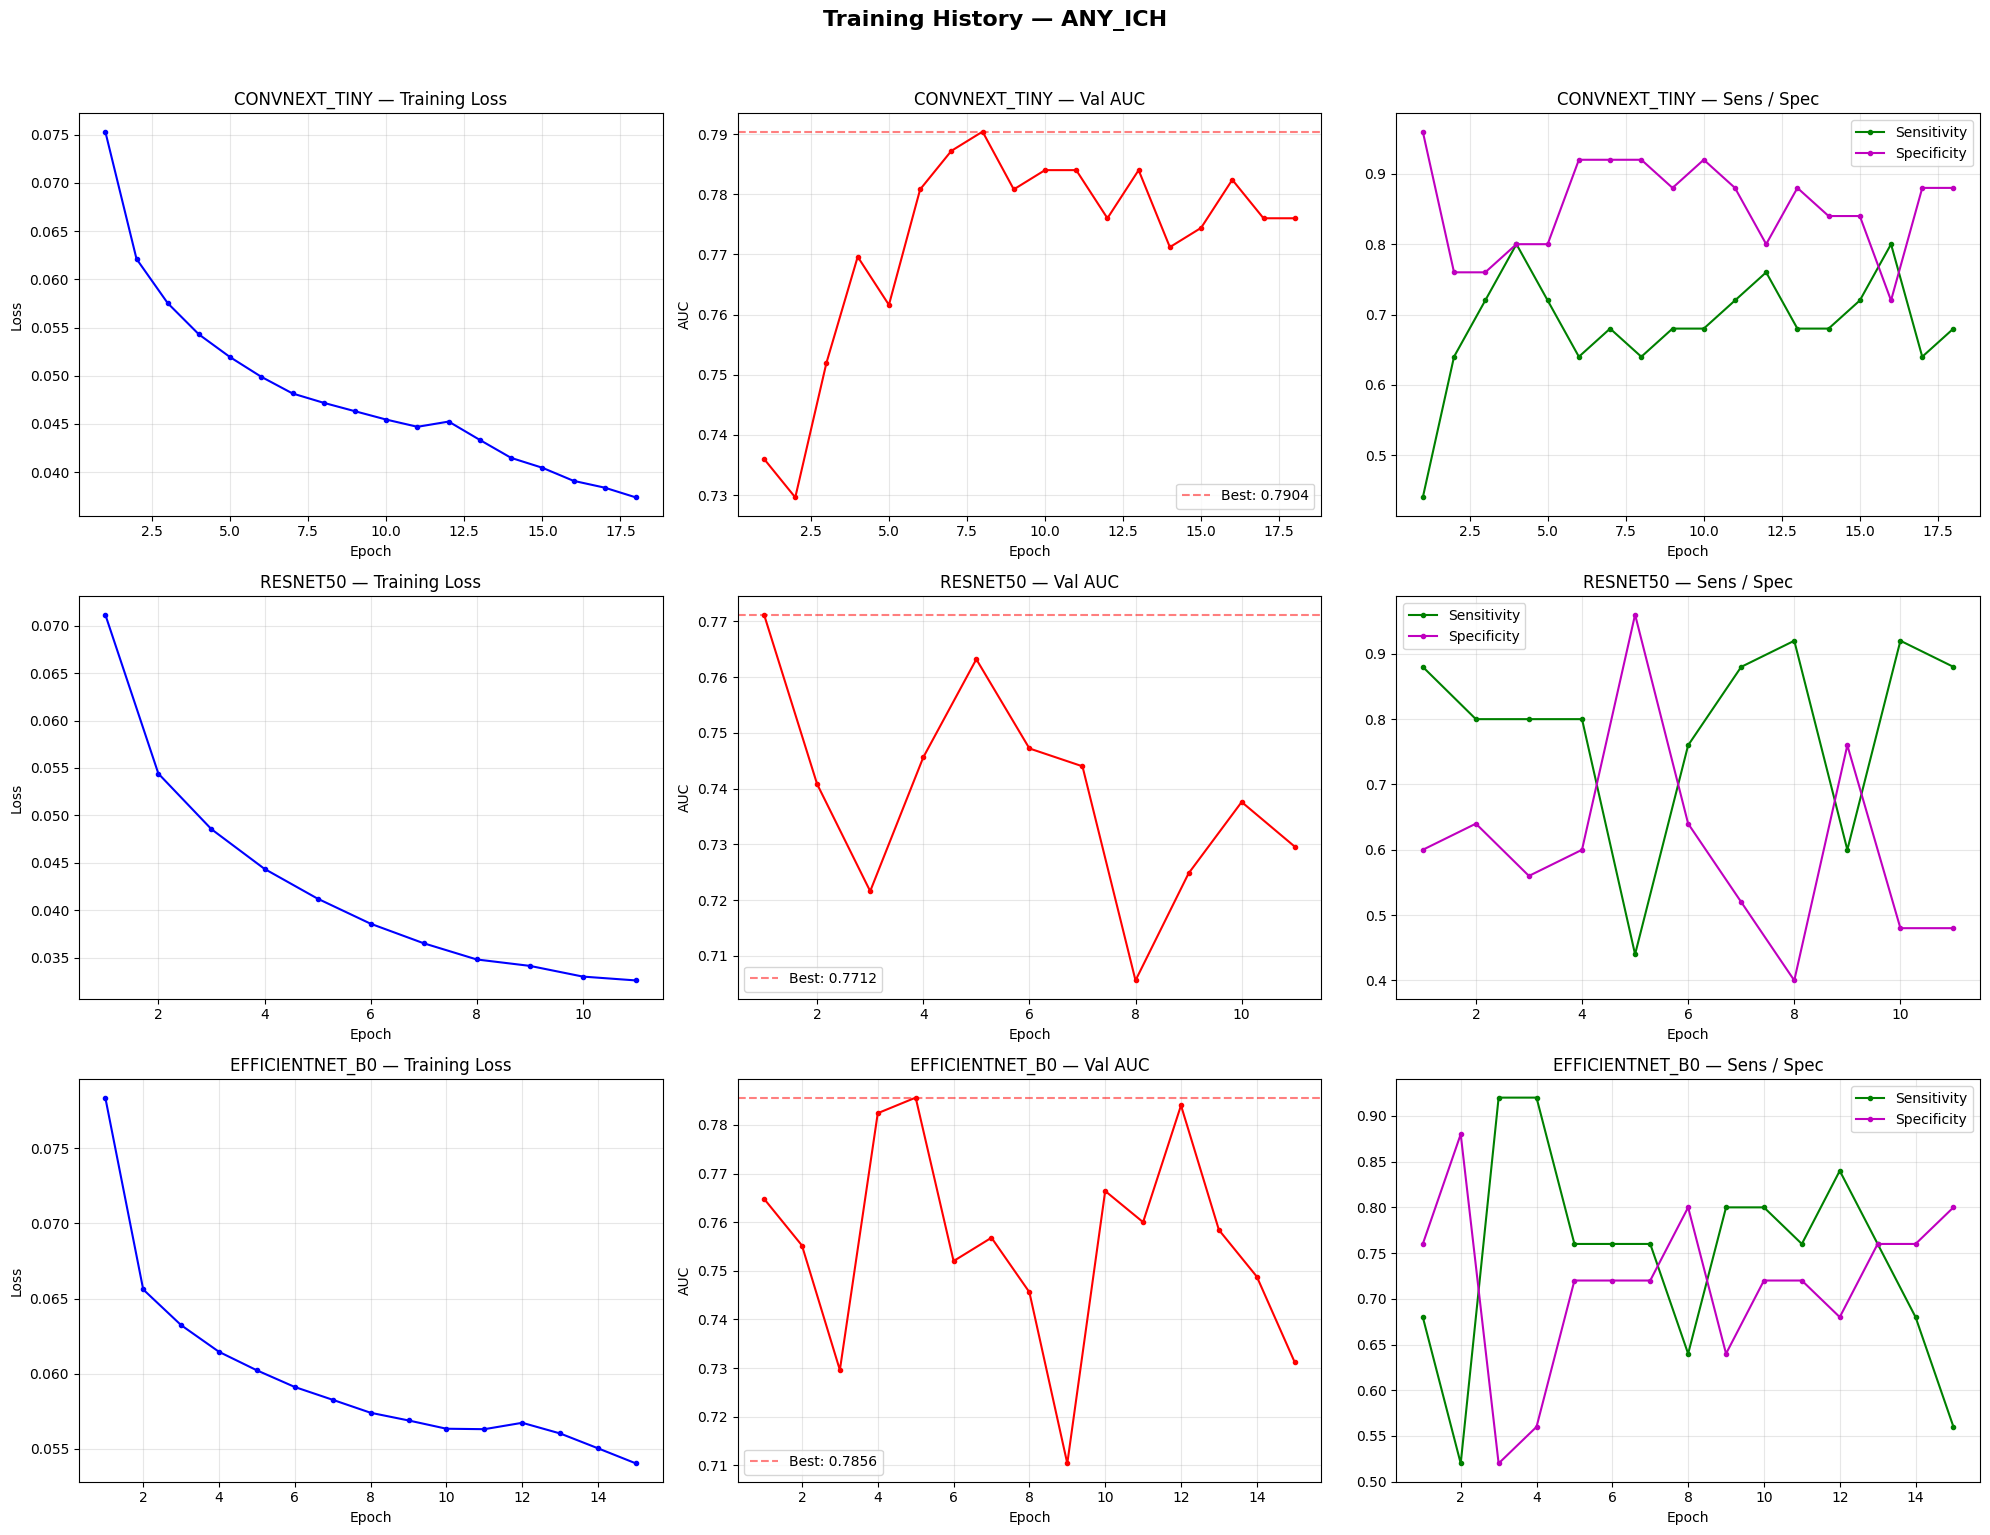

In [22]:
# =====================
# Training History — All Backbones
# =====================
n_bb = len(BACKBONE_NAMES)
fig, axes = plt.subplots(n_bb, 3, figsize=(20, 5 * n_bb))

if n_bb == 1:
    axes = axes.reshape(1, -1)

for row, bb_name in enumerate(BACKBONE_NAMES):
    df_hist = pd.DataFrame(all_histories[bb_name])
    
    # Loss
    axes[row, 0].plot(df_hist["epoch"], df_hist["loss"], "b-o", markersize=3)
    axes[row, 0].set_title(f"{bb_name.upper()} — Training Loss")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].set_ylabel("Loss")
    axes[row, 0].grid(True, alpha=0.3)
    
    # AUC
    best_auc = max(df_hist["auc"])
    axes[row, 1].plot(df_hist["epoch"], df_hist["auc"], "r-o", markersize=3)
    axes[row, 1].axhline(y=best_auc, color="r", linestyle="--", alpha=0.5,
                          label=f"Best: {best_auc:.4f}")
    axes[row, 1].set_title(f"{bb_name.upper()} — Val AUC")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("AUC")
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.3)
    
    # Sensitivity & Specificity
    axes[row, 2].plot(df_hist["epoch"], df_hist["sensitivity"], "g-o", markersize=3, label="Sensitivity")
    axes[row, 2].plot(df_hist["epoch"], df_hist["specificity"], "m-o", markersize=3, label="Specificity")
    axes[row, 2].set_title(f"{bb_name.upper()} — Sens / Spec")
    axes[row, 2].set_xlabel("Epoch")
    axes[row, 2].legend()
    axes[row, 2].grid(True, alpha=0.3)

plt.suptitle(f"Training History — {EXPERIMENT_NAME.upper()}", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [23]:
def load_best_model(backbone_name, experiment_name, device):
    
    model = ICHModel(backbone_name, dropout=0.4)
    
    checkpoint_path = f"/kaggle/working/checkpoints/{experiment_name}/{backbone_name}_best.pt"
    
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    
    # Handle DataParallel prefix if present
    if list(state_dict.keys())[0].startswith("module."):
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    
    model = model.to(device)
    model.load_state_dict(state_dict)
    model.eval()
    
    print(f"Loaded best model from: {checkpoint_path}")
    return model

In [24]:
# ============================================================
# Evaluate ALL backbones on Test Set
# ============================================================
all_test_metrics = {}   # {backbone_name: metrics_dict}

_, _, test_loader = build_loaders(EXPERIMENT_NAME, splits, CACHE_ROOT, batch_size=BATCH_SIZE)

for bb_name in BACKBONE_NAMES:
    
    print(f"\n{'='*50}")
    print(f"  TEST: {bb_name.upper()} on {EXPERIMENT_NAME.upper()}")
    print(f"{'='*50}")
    
    model = load_best_model(bb_name, EXPERIMENT_NAME, DEVICE)
    metrics = validate_patient_level_test(model, test_loader, DEVICE)
    
    all_test_metrics[bb_name] = metrics
    
    print(f"  AUC:          {metrics['auc']:.4f}")
    print(f"  Sensitivity:  {metrics['sensitivity']:.4f}")
    print(f"  Specificity:  {metrics['specificity']:.4f}")
    print(f"  PPV:          {metrics['ppv']:.4f}")
    print(f"  NPV:          {metrics['npv']:.4f}")
    print(f"  Accuracy:     {metrics['accuracy']:.4f}")
    print(f"  Threshold:    {metrics['threshold']:.4f}")

print(f"\n{'='*50}")
print(f"All {len(BACKBONE_NAMES)} backbones evaluated on {EXPERIMENT_NAME.upper()}.")
print(f"{'='*50}")

  [any_ich] Train: 72526 slices (35077 pos, 37449 neg) | Val: 14720 | Test: 15223

  TEST: CONVNEXT_TINY on ANY_ICH
Loaded best model from: /kaggle/working/checkpoints/any_ich/convnext_tiny_best.pt
  AUC:          0.8826
  Sensitivity:  0.6250
  Specificity:  1.0000
  PPV:          1.0000
  NPV:          0.7097
  Accuracy:     0.8043
  Threshold:    0.7879

  TEST: RESNET50 on ANY_ICH
Loaded best model from: /kaggle/working/checkpoints/any_ich/resnet50_best.pt
  AUC:          0.8049
  Sensitivity:  0.5833
  Specificity:  0.9545
  PPV:          0.9333
  NPV:          0.6774
  Accuracy:     0.7609
  Threshold:    0.7341

  TEST: EFFICIENTNET_B0 on ANY_ICH
Loaded best model from: /kaggle/working/checkpoints/any_ich/efficientnet_b0_best.pt
  AUC:          0.9299
  Sensitivity:  0.7083
  Specificity:  1.0000
  PPV:          1.0000
  NPV:          0.7586
  Accuracy:     0.8478
  Threshold:    0.6840

All 3 backbones evaluated on ANY_ICH.


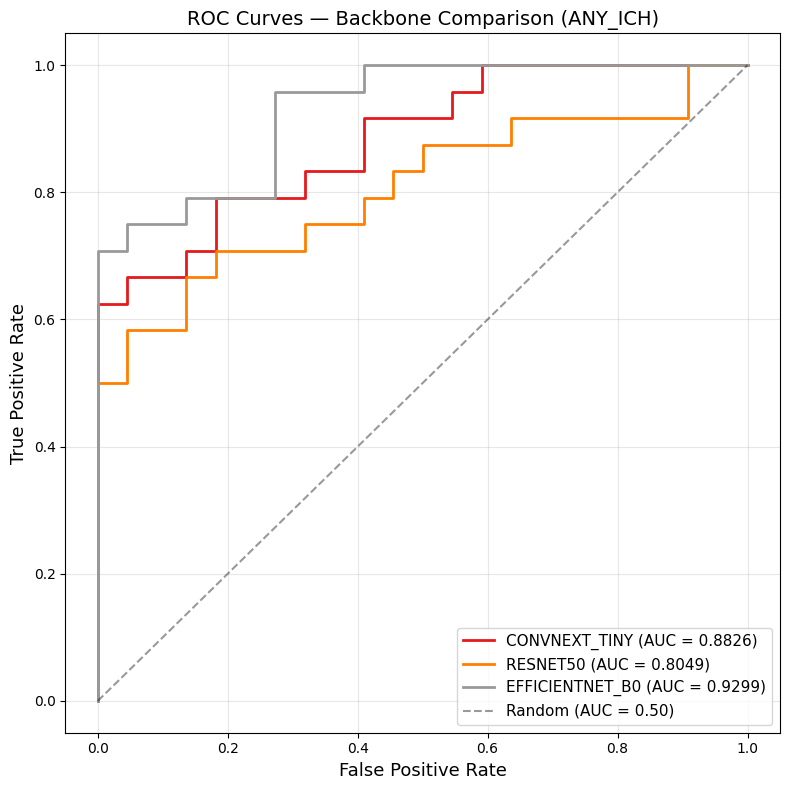

In [25]:
# ============================================================
# Combined ROC Curves — All Backbones Overlaid
# ============================================================
colors = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

plt.figure(figsize=(8, 8))

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    fpr, tpr, _ = roc_curve(m["y_true"], m["y_pred"])
    plt.plot(fpr, tpr, color=colors[i], linewidth=2,
             label=f"{bb_name.upper()} (AUC = {m['auc']:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC = 0.50)")
plt.xlabel("False Positive Rate", fontsize=13)
plt.ylabel("True Positive Rate", fontsize=13)
plt.title(f"ROC Curves — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

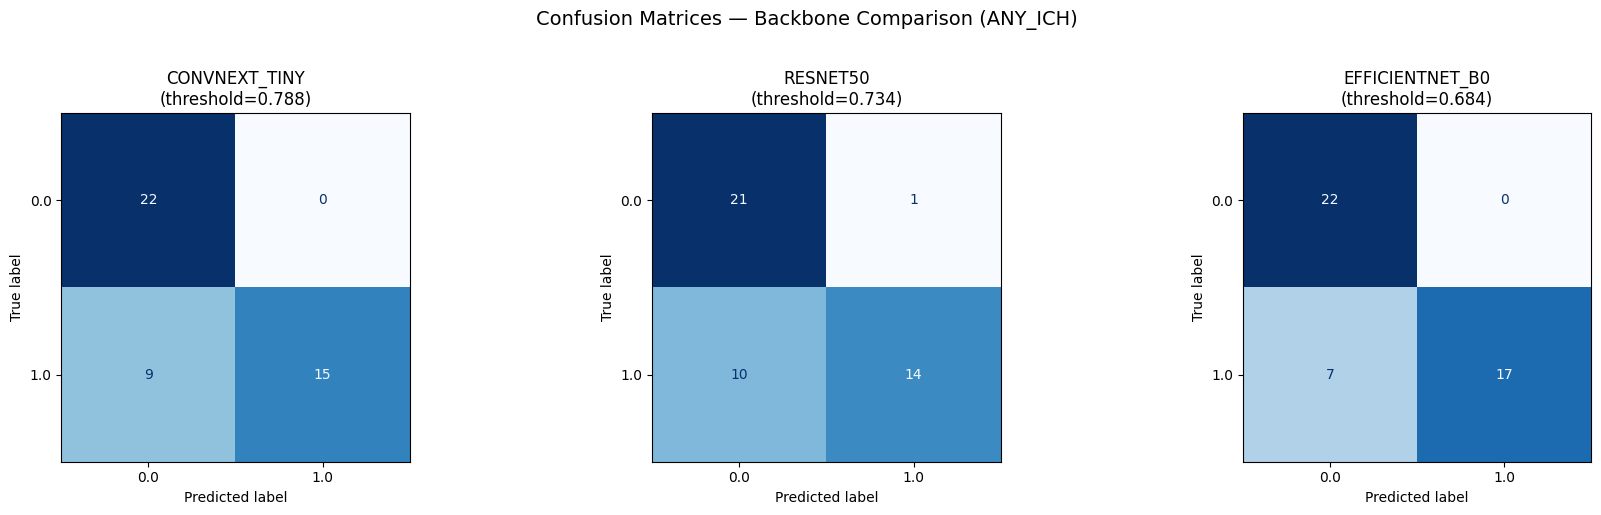

In [26]:
# ============================================================
# Confusion Matrices — All Backbones
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay

n_cols = min(3, len(BACKBONE_NAMES))
n_rows = int(np.ceil(len(BACKBONE_NAMES) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).flatten()

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    threshold = m["threshold"]
    y_pred_binary = (m["y_pred"] >= threshold).astype(int)
    
    ConfusionMatrixDisplay.from_predictions(
        m["y_true"], y_pred_binary, ax=axes[i],
        cmap="Blues", colorbar=False
    )
    axes[i].set_title(f"{bb_name.upper()}\n(threshold={threshold:.3f})", fontsize=12)

for j in range(len(BACKBONE_NAMES), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Confusion Matrices — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# Summary Metrics Table — All Backbones
# ============================================================
rows = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    rows.append({
        "Backbone": bb_name.upper(),
        "AUC": f"{m['auc']:.4f}",
        "Sensitivity": f"{m['sensitivity']:.4f}",
        "Specificity": f"{m['specificity']:.4f}",
        "PPV": f"{m['ppv']:.4f}",
        "NPV": f"{m['npv']:.4f}",
        "Accuracy": f"{m['accuracy']:.4f}",
        "Threshold": f"{m['threshold']:.4f}",
    })

df_summary = pd.DataFrame(rows)
print("=" * 90)
print(f"  TEST SET RESULTS — Backbone Comparison ({EXPERIMENT_NAME.upper()})")
print("=" * 90)
display(df_summary.style.set_properties(**{
    'text-align': 'center',
    'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))

  TEST SET RESULTS — Backbone Comparison (ANY_ICH)


,Backbone,AUC,Sensitivity,Specificity,PPV,NPV,Accuracy,Threshold
0,CONVNEXT_TINY,0.8826,0.6250,1.0000,1.0000,0.7097,0.8043,0.7879
1,RESNET50,0.8049,0.5833,0.9545,0.9333,0.6774,0.7609,0.7341
2,EFFICIENTNET_B0,0.9299,0.7083,1.0000,1.0000,0.7586,0.8478,0.6840


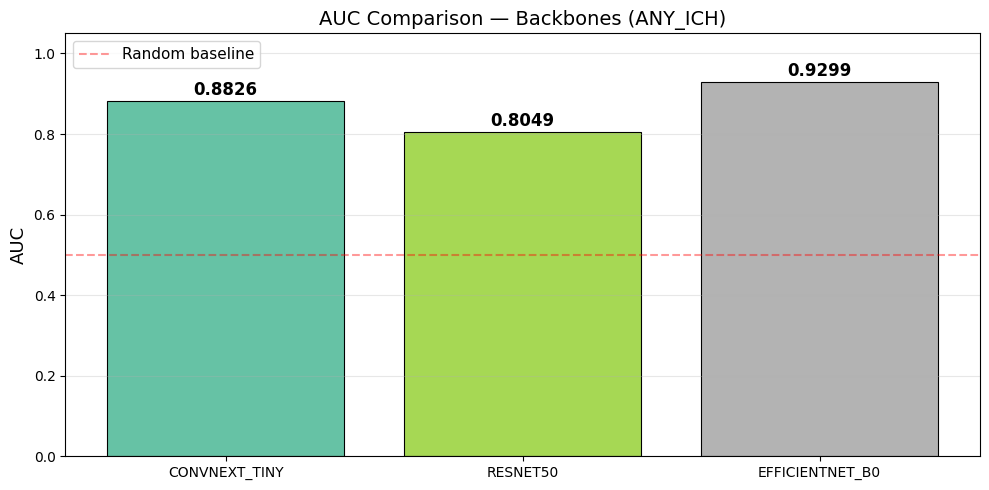

In [28]:
# ============================================================
# AUC Bar Chart Comparison — All Backbones
# ============================================================
auc_values = [all_test_metrics[b]["auc"] for b in BACKBONE_NAMES]
bb_labels = [b.upper() for b in BACKBONE_NAMES]
bar_colors = plt.cm.Set2(np.linspace(0, 1, len(BACKBONE_NAMES)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bb_labels, auc_values, color=bar_colors, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, auc_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel("AUC", fontsize=13)
ax.set_title(f"AUC Comparison — Backbones ({EXPERIMENT_NAME.upper()})", fontsize=14)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.4, label="Random baseline")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

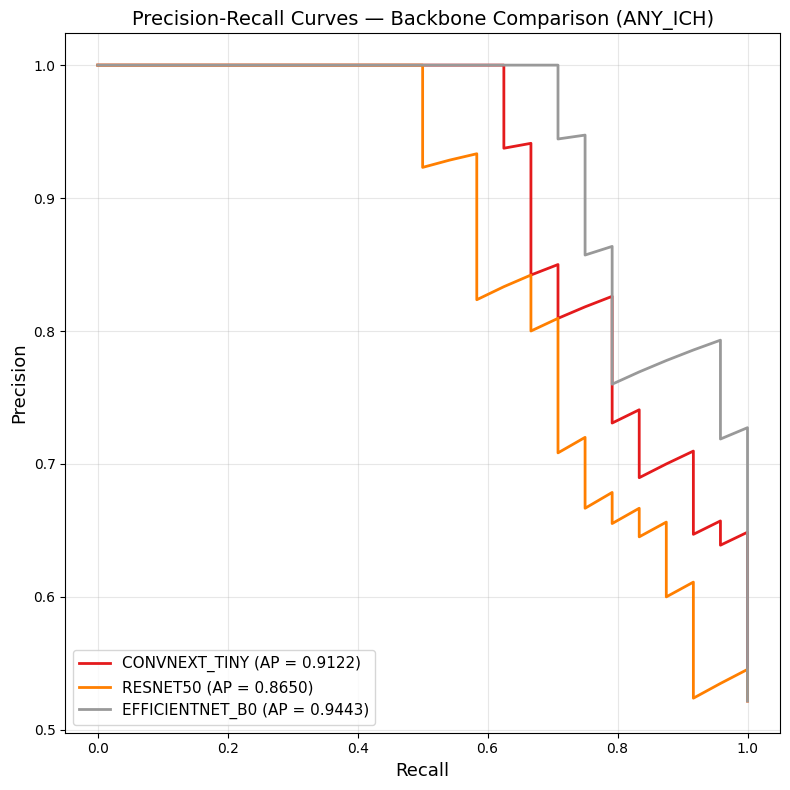

In [29]:
# ============================================================
# Combined Precision-Recall Curves — All Backbones
# ============================================================
colors_pr = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

plt.figure(figsize=(8, 8))

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    precision, recall, _ = precision_recall_curve(m["y_true"], m["y_pred"])
    ap = average_precision_score(m["y_true"], m["y_pred"])
    plt.plot(recall, precision, color=colors_pr[i], linewidth=2,
             label=f"{bb_name.upper()} (AP = {ap:.4f})")

plt.xlabel("Recall", fontsize=13)
plt.ylabel("Precision", fontsize=13)
plt.title(f"Precision-Recall Curves — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14)
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

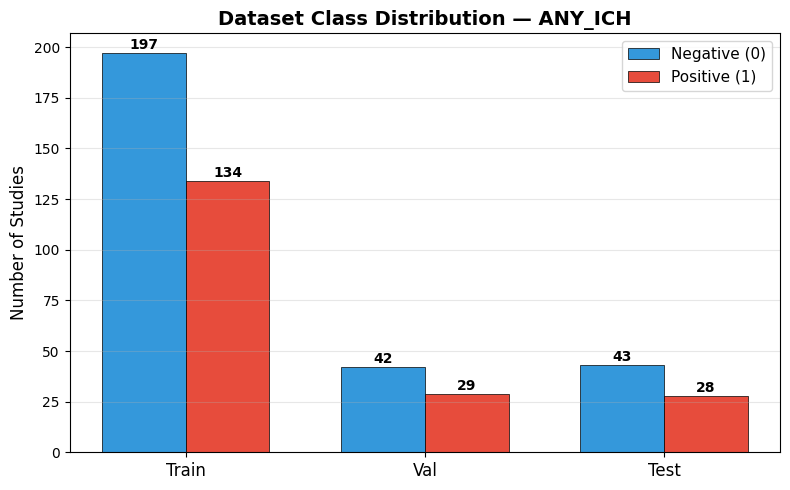

In [30]:
# ============================================================
# Fig. 1 — Dataset Class Distribution (Single Experiment)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

subsets = ["train", "val", "test"]
pos_counts = []
neg_counts = []
for s in subsets:
    df_s = splits[EXPERIMENT_NAME][s]
    pos_counts.append(int(df_s["label"].sum()))
    neg_counts.append(int(len(df_s) - df_s["label"].sum()))

x = np.arange(len(subsets))
w = 0.35
bars_neg = ax.bar(x - w/2, neg_counts, w, label="Negative (0)", color="#3498db", edgecolor="black", linewidth=0.5)
bars_pos = ax.bar(x + w/2, pos_counts, w, label="Positive (1)", color="#e74c3c", edgecolor="black", linewidth=0.5)

for bar in bars_neg:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_pos:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(["Train", "Val", "Test"], fontsize=12)
ax.set_ylabel("Number of Studies", fontsize=12)
ax.set_title(f"Dataset Class Distribution — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

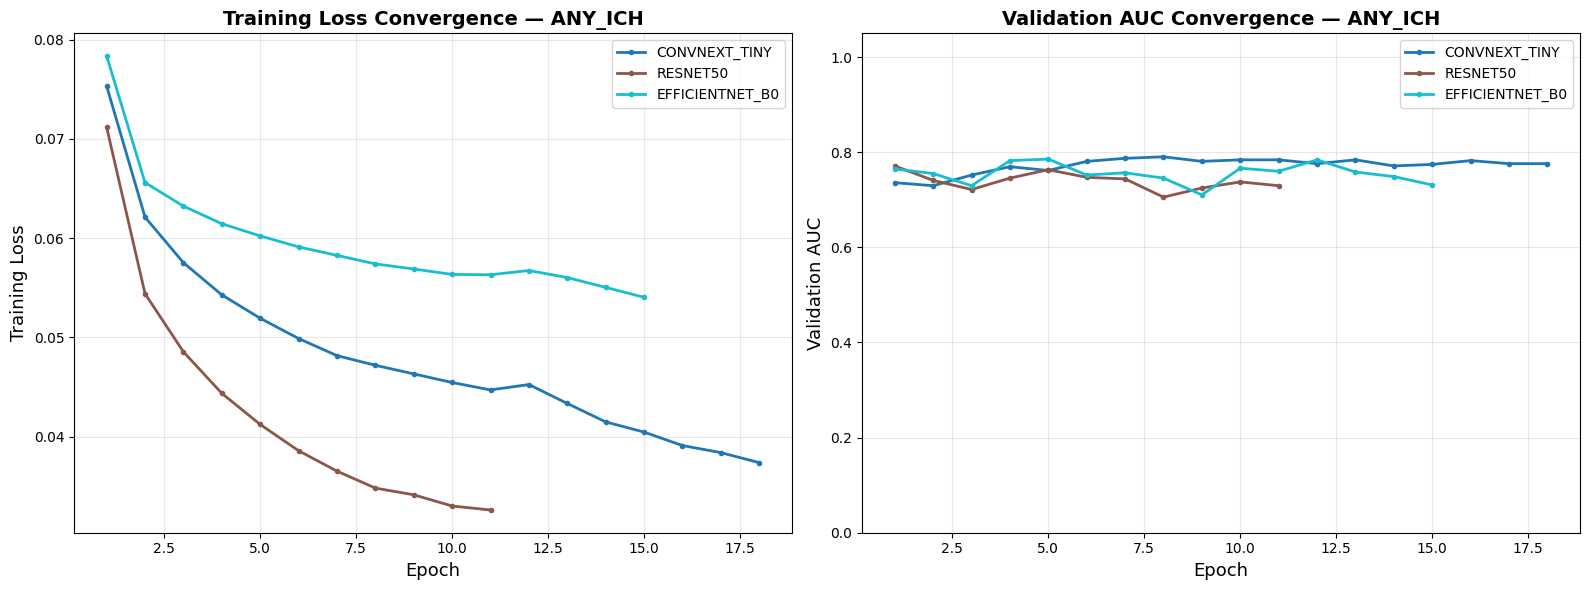

In [31]:
# ============================================================
# Fig. 2 — Training Convergence Overlay (Loss & AUC) — All Backbones
# ============================================================
colors_conv = plt.cm.tab10(np.linspace(0, 1, len(BACKBONE_NAMES)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i, bb_name in enumerate(BACKBONE_NAMES):
    df_h = pd.DataFrame(all_histories[bb_name])
    ax1.plot(df_h["epoch"], df_h["loss"], color=colors_conv[i], linewidth=2,
             marker='o', markersize=3, label=bb_name.upper())
    ax2.plot(df_h["epoch"], df_h["auc"], color=colors_conv[i], linewidth=2,
             marker='o', markersize=3, label=bb_name.upper())

ax1.set_xlabel("Epoch", fontsize=13)
ax1.set_ylabel("Training Loss", fontsize=13)
ax1.set_title(f"Training Loss Convergence — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Epoch", fontsize=13)
ax2.set_ylabel("Validation AUC", fontsize=13)
ax2.set_title(f"Validation AUC Convergence — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

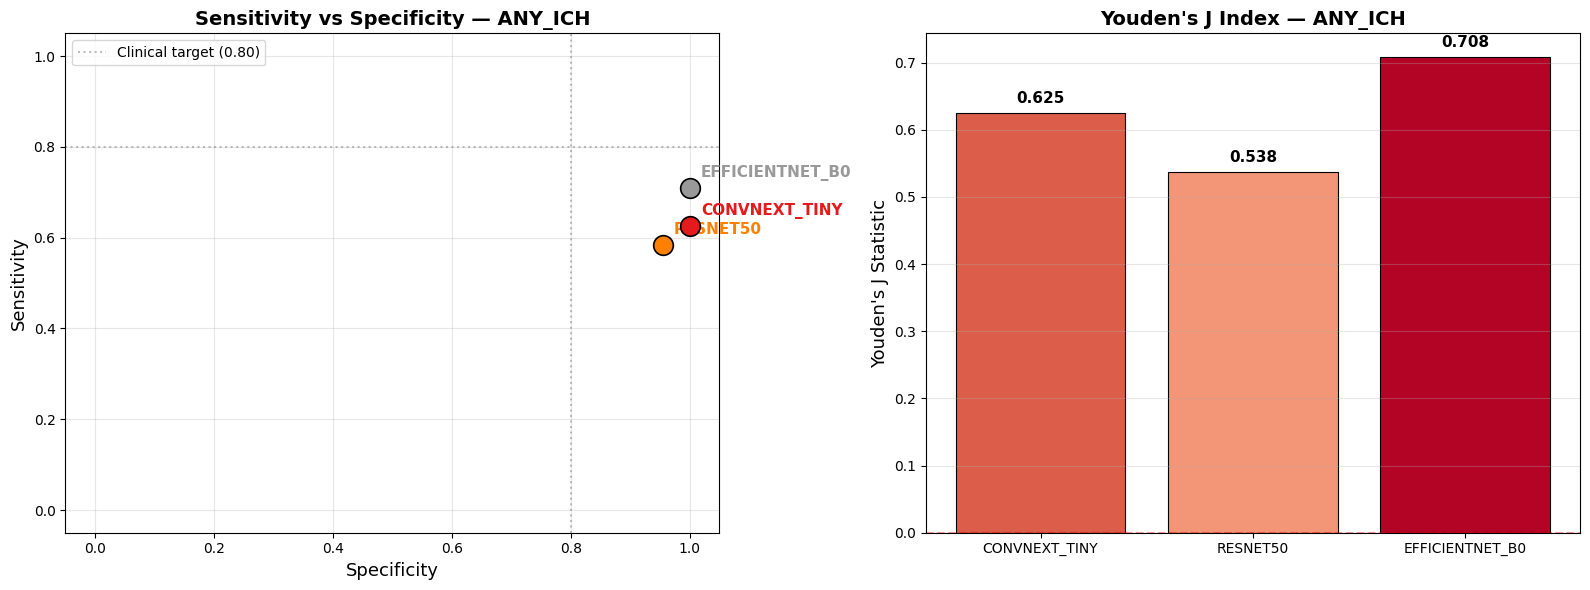

In [32]:
# ============================================================
# Fig. 4 — Sensitivity vs Specificity Trade-off Scatter
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter_colors = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    ax1.scatter(m["specificity"], m["sensitivity"], color=scatter_colors[i],
                s=200, edgecolor="black", linewidth=1.2, zorder=5)
    ax1.annotate(bb_name.upper(),
                 (m["specificity"], m["sensitivity"]),
                 textcoords="offset points", xytext=(8, 8),
                 fontsize=11, fontweight="bold", color=scatter_colors[i])

ax1.set_xlabel("Specificity", fontsize=13)
ax1.set_ylabel("Sensitivity", fontsize=13)
ax1.set_title(f"Sensitivity vs Specificity — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.axhline(y=0.8, color="gray", linestyle=":", alpha=0.5, label="Clinical target (0.80)")
ax1.axvline(x=0.8, color="gray", linestyle=":", alpha=0.5)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ============================================================
# Fig. 5 — Youden's J Statistic
# ============================================================
youden_values = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    j_stat = m["sensitivity"] + m["specificity"] - 1
    youden_values.append(j_stat)

bar_colors_j = plt.cm.coolwarm(np.array(youden_values) / max(max(youden_values), 0.01))
bars = ax2.bar([b.upper() for b in BACKBONE_NAMES], youden_values,
               color=bar_colors_j, edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, youden_values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel("Youden's J Statistic", fontsize=13)
ax2.set_title(f"Youden's J Index — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
ax2.axhline(y=0, color="red", linestyle="--", alpha=0.4)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

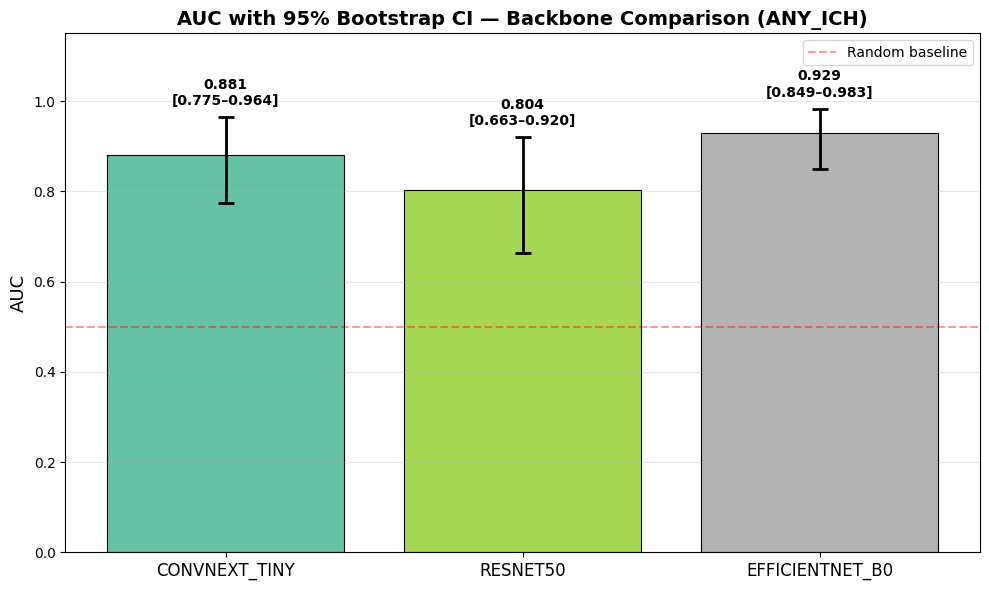


  AUC with 95% Bootstrap CI — ANY_ICH
       CONVNEXT_TINY  |  AUC: 0.8814  (95% CI: 0.7746 – 0.9638)
            RESNET50  |  AUC: 0.8035  (95% CI: 0.6633 – 0.9205)
     EFFICIENTNET_B0  |  AUC: 0.9288  (95% CI: 0.8495 – 0.9830)


In [33]:
# ============================================================
# Fig. 7 — AUC with 95% Confidence Intervals (Bootstrap) per Backbone
# ============================================================
from sklearn.utils import resample

def bootstrap_auc(y_true, y_pred, n_bootstraps=1000, seed=42):
    """Compute AUC with 95% CI using bootstrap resampling."""
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_bootstraps):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_t = y_true[idx]
        y_p = y_pred[idx]
        if len(np.unique(y_t)) < 2:
            continue
        aucs.append(roc_auc_score(y_t, y_p))
    aucs = np.array(aucs)
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

# Compute CIs
ci_results = {}
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    mean_auc, ci_low, ci_high = bootstrap_auc(m["y_true"], m["y_pred"])
    ci_results[bb_name] = {"mean": mean_auc, "ci_low": ci_low, "ci_high": ci_high}

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(BACKBONE_NAMES))
means = [ci_results[b]["mean"] for b in BACKBONE_NAMES]
ci_lows = [ci_results[b]["ci_low"] for b in BACKBONE_NAMES]
ci_highs = [ci_results[b]["ci_high"] for b in BACKBONE_NAMES]
errors = [[m - lo for m, lo in zip(means, ci_lows)],
          [hi - m for m, hi in zip(means, ci_highs)]]

bar_colors = plt.cm.Set2(np.linspace(0, 1, len(BACKBONE_NAMES)))
bars = ax.bar(x, means, color=bar_colors, edgecolor="black", linewidth=0.8, yerr=errors,
              capsize=6, error_kw=dict(lw=2, capthick=2))

for xi, m, lo, hi in zip(x, means, ci_lows, ci_highs):
    ax.text(xi, hi + 0.02, f"{m:.3f}\n[{lo:.3f}–{hi:.3f}]",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=12)
ax.set_ylabel("AUC", fontsize=13)
ax.set_title(f"AUC with 95% Bootstrap CI — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color="red", linestyle="--", alpha=0.4, label="Random baseline")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Print CI table
print("\n" + "=" * 65)
print(f"  AUC with 95% Bootstrap CI — {EXPERIMENT_NAME.upper()}")
print("=" * 65)
for bb_name in BACKBONE_NAMES:
    r = ci_results[bb_name]
    print(f"  {bb_name.upper():>18s}  |  AUC: {r['mean']:.4f}  "
          f"(95% CI: {r['ci_low']:.4f} – {r['ci_high']:.4f})")
print("=" * 65)

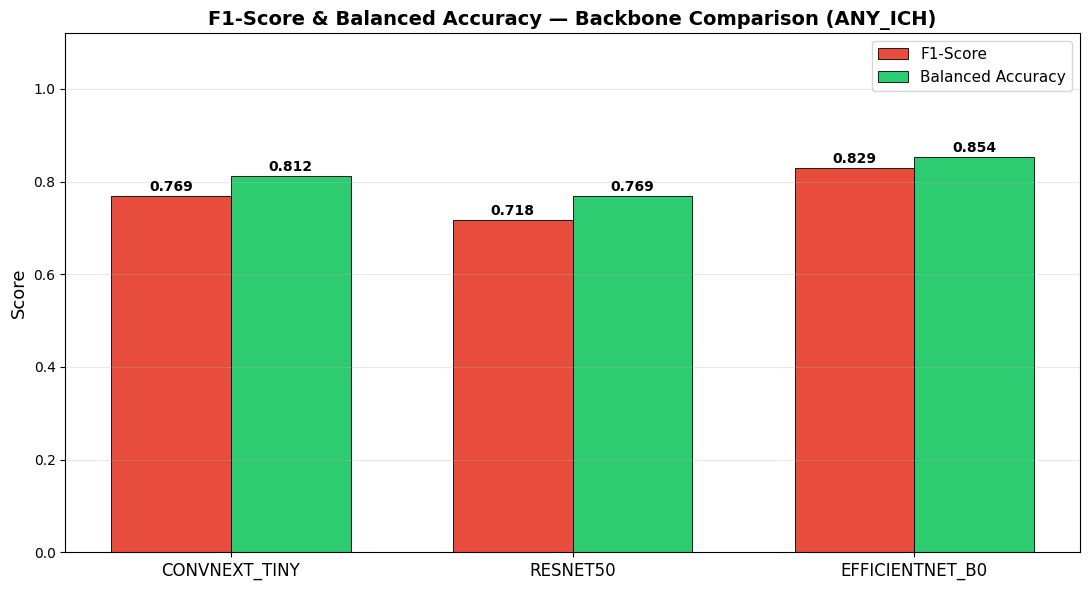

In [34]:
# ============================================================
# Fig. 8 — F1-Score & Balanced Accuracy Comparison per Backbone
# ============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score

f1_values = []
bal_acc_values = []

for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    y_bin = (m["y_pred"] >= m["threshold"]).astype(int)
    f1_values.append(f1_score(m["y_true"], y_bin))
    bal_acc_values.append(balanced_accuracy_score(m["y_true"], y_bin))

x = np.arange(len(BACKBONE_NAMES))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - w/2, f1_values, w, label="F1-Score", color="#e74c3c", edgecolor="black", linewidth=0.6)
bars2 = ax.bar(x + w/2, bal_acc_values, w, label="Balanced Accuracy", color="#2ecc71", edgecolor="black", linewidth=0.6)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=12)
ax.set_ylabel("Score", fontsize=13)
ax.set_title(f"F1-Score & Balanced Accuracy — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

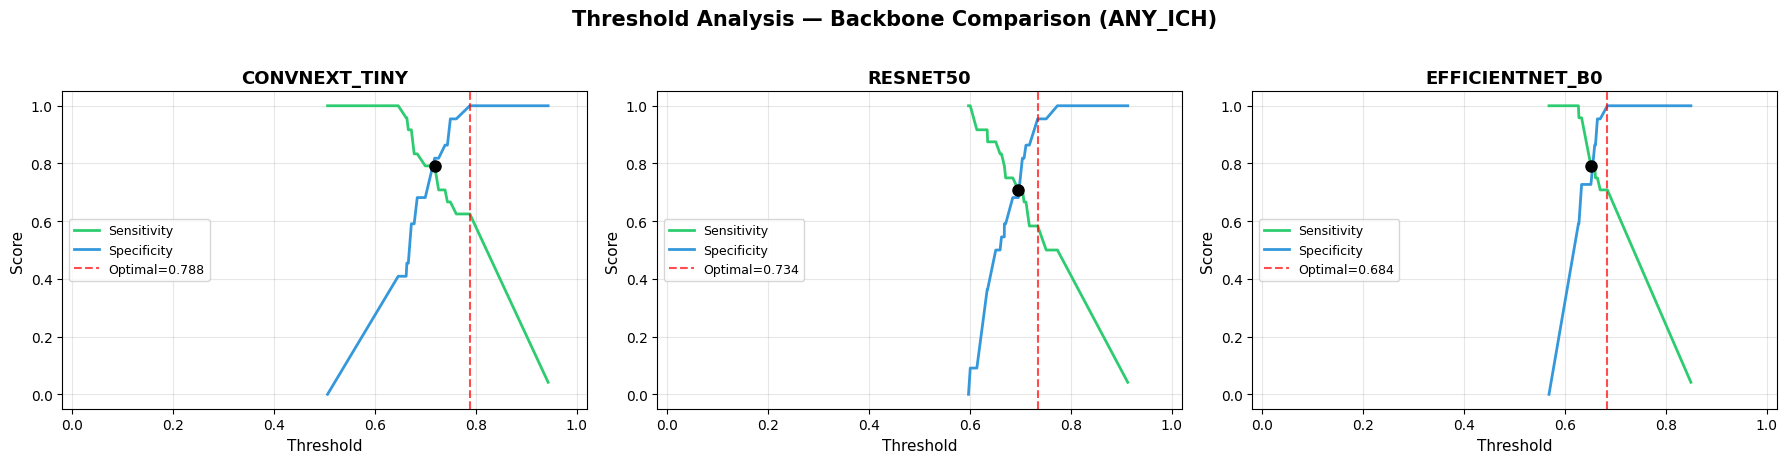

In [35]:
# ============================================================
# Fig. 10 — Threshold vs Sensitivity/Specificity (Per Backbone)
# ============================================================
n_cols = min(3, len(BACKBONE_NAMES))
n_rows = int(np.ceil(len(BACKBONE_NAMES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = np.array(axes).flatten()

for i, bb_name in enumerate(BACKBONE_NAMES):
    m = all_test_metrics[bb_name]
    fpr, tpr, thresholds = roc_curve(m["y_true"], m["y_pred"])
    sens = tpr
    spec = 1 - fpr
    
    axes[i].plot(thresholds, sens, color="#2ecc71", linewidth=2, label="Sensitivity")
    axes[i].plot(thresholds, spec, color="#3498db", linewidth=2, label="Specificity")
    
    axes[i].axvline(x=m["threshold"], color="red", linestyle="--", alpha=0.7,
                     label=f"Optimal={m['threshold']:.3f}")
    
    diff = np.abs(sens - spec)
    cross_idx = np.argmin(diff)
    axes[i].plot(thresholds[cross_idx], sens[cross_idx], 'ko', markersize=8)
    
    axes[i].set_xlabel("Threshold", fontsize=11)
    axes[i].set_ylabel("Score", fontsize=11)
    axes[i].set_title(f"{bb_name.upper()}", fontsize=13, fontweight="bold")
    axes[i].legend(fontsize=9, loc="center left")
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-0.02, 1.02)

for j in range(len(BACKBONE_NAMES), len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Threshold Analysis — Backbone Comparison ({EXPERIMENT_NAME.upper()})", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# Table 1 — Full Academic Report Table (with 95% CI for AUC)
# ============================================================
from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef

report_rows = []
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    ci = ci_results[bb_name]
    y_bin = (m["y_pred"] >= m["threshold"]).astype(int)
    
    f1 = f1_score(m["y_true"], y_bin)
    bal_acc = balanced_accuracy_score(m["y_true"], y_bin)
    mcc = matthews_corrcoef(m["y_true"], y_bin)
    ap = average_precision_score(m["y_true"], m["y_pred"])
    
    j_stat = m["sensitivity"] + m["specificity"] - 1
    
    report_rows.append({
        "Backbone": bb_name.upper(),
        "AUC": f"{ci['mean']:.4f}",
        "95% CI": f"[{ci['ci_low']:.4f}–{ci['ci_high']:.4f}]",
        "Sens": f"{m['sensitivity']:.4f}",
        "Spec": f"{m['specificity']:.4f}",
        "PPV": f"{m['ppv']:.4f}",
        "NPV": f"{m['npv']:.4f}",
        "F1": f"{f1:.4f}",
        "Bal Acc": f"{bal_acc:.4f}",
        "MCC": f"{mcc:.4f}",
        "AP": f"{ap:.4f}",
        "Youden J": f"{j_stat:.4f}",
    })

df_report = pd.DataFrame(report_rows)

print("=" * 120)
print(f"  TABLE 1: Complete Performance Metrics — Backbone Comparison ({EXPERIMENT_NAME.upper()})")
print("=" * 120)
display(df_report.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold'), ('font-size', '11px')]}
]))

  TABLE 1: Complete Performance Metrics — Backbone Comparison (ANY_ICH)


,Backbone,AUC,95% CI,Sens,Spec,PPV,NPV,F1,Bal Acc,MCC,AP,Youden J
0,CONVNEXT_TINY,0.8814,[0.7746–0.9638],0.6250,1.0000,1.0000,0.7097,0.7692,0.8125,0.6660,0.9122,0.6250
1,RESNET50,0.8035,[0.6633–0.9205],0.5833,0.9545,0.9333,0.6774,0.7179,0.7689,0.5732,0.8650,0.5379
2,EFFICIENTNET_B0,0.9288,[0.8495–0.9830],0.7083,1.0000,1.0000,0.7586,0.8293,0.8542,0.7330,0.9443,0.7083


In [37]:
# ============================================================
# Table 2 — Training Statistics Summary per Backbone
# ============================================================
train_summary_rows = []
for bb_name in BACKBONE_NAMES:
    hist = all_histories[bb_name]
    df_h = pd.DataFrame(hist)
    
    best_epoch = df_h.loc[df_h["auc"].idxmax(), "epoch"]
    total_epochs = len(df_h)
    final_loss = df_h.iloc[-1]["loss"]
    best_auc_val = df_h["auc"].max()
    final_train_acc = df_h.iloc[-1]["train_acc"]
    
    train_summary_rows.append({
        "Backbone": bb_name.upper(),
        "Total Epochs": total_epochs,
        "Best Epoch": int(best_epoch),
        "Final Loss": f"{final_loss:.4f}",
        "Best Val AUC": f"{best_auc_val:.4f}",
        "Final Train Acc": f"{final_train_acc:.4f}",
        "Early Stopped": "Yes" if total_epochs < EPOCHS else "No"
    })

df_train_summary = pd.DataFrame(train_summary_rows)
print("\n" + "=" * 90)
print(f"  TABLE 2: Training Statistics Summary — {EXPERIMENT_NAME.upper()}")
print("=" * 90)
display(df_train_summary.style.set_properties(**{
    'text-align': 'center', 'font-size': '12px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))


  TABLE 2: Training Statistics Summary — ANY_ICH


,Backbone,Total Epochs,Best Epoch,Final Loss,Best Val AUC,Final Train Acc,Early Stopped
0,CONVNEXT_TINY,18,8,0.0374,0.7904,0.8061,Yes
1,RESNET50,11,1,0.0326,0.7712,0.8413,Yes
2,EFFICIENTNET_B0,15,5,0.0540,0.7856,0.6802,Yes


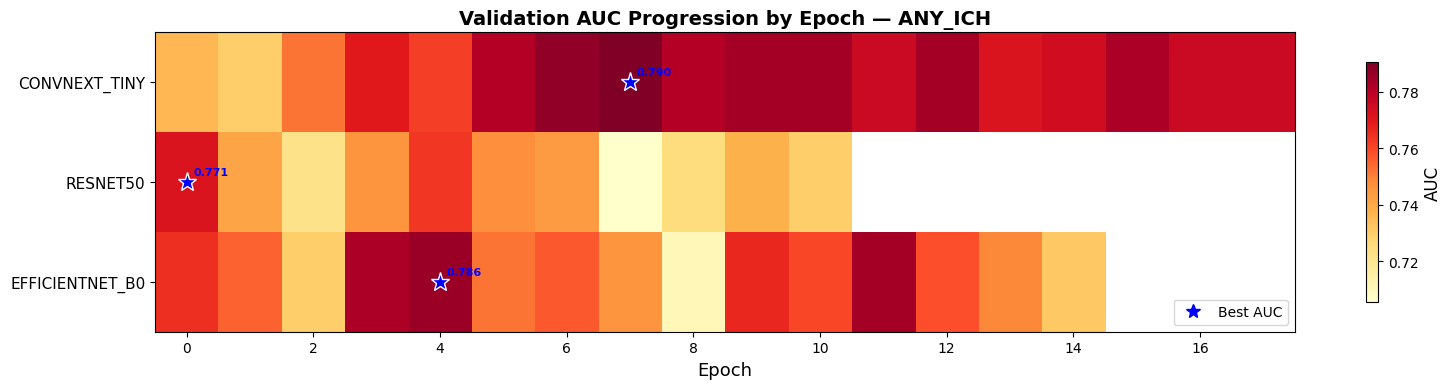

In [38]:
# ============================================================
# Fig. 12 — Epoch-wise AUC Heatmap Across Backbones
# ============================================================
max_epochs = max(len(all_histories[b]) for b in BACKBONE_NAMES)
auc_matrix = np.full((len(BACKBONE_NAMES), max_epochs), np.nan)

for i, bb_name in enumerate(BACKBONE_NAMES):
    aucs = [h["auc"] for h in all_histories[bb_name]]
    auc_matrix[i, :len(aucs)] = aucs

fig, ax = plt.subplots(figsize=(16, max(4, len(BACKBONE_NAMES) * 0.8)))
im = ax.imshow(auc_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(len(BACKBONE_NAMES)))
ax.set_yticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=11)
ax.set_xlabel("Epoch", fontsize=13)
ax.set_title(f"Validation AUC Progression by Epoch — {EXPERIMENT_NAME.upper()}", fontsize=14, fontweight="bold")
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("AUC", fontsize=12)

for i, bb_name in enumerate(BACKBONE_NAMES):
    aucs = [h["auc"] for h in all_histories[bb_name]]
    best_ep = int(np.argmax(aucs))
    ax.plot(best_ep, i, marker='*', color='blue', markersize=14, markeredgecolor='white', markeredgewidth=1)
    ax.annotate(f"{aucs[best_ep]:.3f}", (best_ep, i), textcoords="offset points",
                xytext=(5, 5), fontsize=8, color='blue', fontweight='bold')

ax.legend(handles=[plt.Line2D([0], [0], marker='*', color='blue', linestyle='', markersize=10, label='Best AUC')],
          loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()


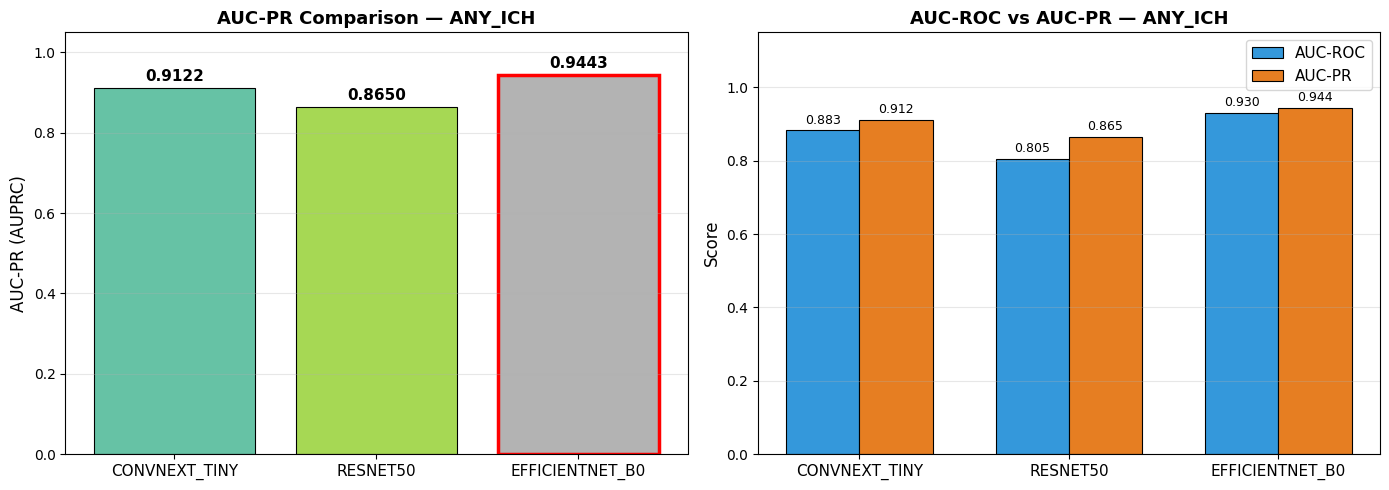


  AUC-PR (AUPRC) Results — ANY_ICH
  CONVNEXT_TINY         AUC-PR = 0.9122
  RESNET50              AUC-PR = 0.8650
  EFFICIENTNET_B0       AUC-PR = 0.9443


In [39]:
# ==============================================================
# Fig. 14 — AUC-PR (AUPRC) Comparison per Backbone
# ==============================================================
from sklearn.metrics import average_precision_score, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Bar chart of AUPRC ---
auprc_vals = {}
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    auprc_vals[bb_name] = average_precision_score(m["y_true"], m["y_pred"])

colors = plt.cm.Set2(np.linspace(0, 1, len(BACKBONE_NAMES)))
bars = axes[0].bar(range(len(BACKBONE_NAMES)),
                   [auprc_vals[b] for b in BACKBONE_NAMES],
                   color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_xticks(range(len(BACKBONE_NAMES)))
axes[0].set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=11)
axes[0].set_ylabel("AUC-PR (AUPRC)", fontsize=12)
axes[0].set_title(f"AUC-PR Comparison — {EXPERIMENT_NAME.upper()}", fontsize=13, fontweight="bold")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='y')

for bar, bb_name in zip(bars, BACKBONE_NAMES):
    val = auprc_vals[bb_name]
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Highlight the best
best_bb = max(auprc_vals, key=auprc_vals.get)
best_idx = BACKBONE_NAMES.index(best_bb)
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(2.5)

# --- Right: AUC-ROC vs AUC-PR side-by-side ---
x = np.arange(len(BACKBONE_NAMES))
width = 0.35

auc_roc_vals = [all_test_metrics[b]["auc"] if "auc" in all_test_metrics[b]
                else roc_auc_score(all_test_metrics[b]["y_true"], all_test_metrics[b]["y_pred"])
                for b in BACKBONE_NAMES]
auc_pr_vals = [auprc_vals[b] for b in BACKBONE_NAMES]

rects1 = axes[1].bar(x - width/2, auc_roc_vals, width, label='AUC-ROC', color='#3498db', edgecolor='black', linewidth=0.8)
rects2 = axes[1].bar(x + width/2, auc_pr_vals, width, label='AUC-PR', color='#e67e22', edgecolor='black', linewidth=0.8)

axes[1].set_xticks(x)
axes[1].set_xticklabels([b.upper() for b in BACKBONE_NAMES], fontsize=11)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title(f"AUC-ROC vs AUC-PR — {EXPERIMENT_NAME.upper()}", fontsize=13, fontweight="bold")
axes[1].set_ylim(0, 1.15)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

for rect in rects1:
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
                 f"{rect.get_height():.3f}", ha='center', va='bottom', fontsize=9)
for rect in rects2:
    axes[1].text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.01,
                 f"{rect.get_height():.3f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"  AUC-PR (AUPRC) Results — {EXPERIMENT_NAME.upper()}")
print(f"{'='*60}")
for bb_name in BACKBONE_NAMES:
    print(f"  {bb_name.upper():20s}  AUC-PR = {auprc_vals[bb_name]:.4f}")
print(f"{'='*60}")

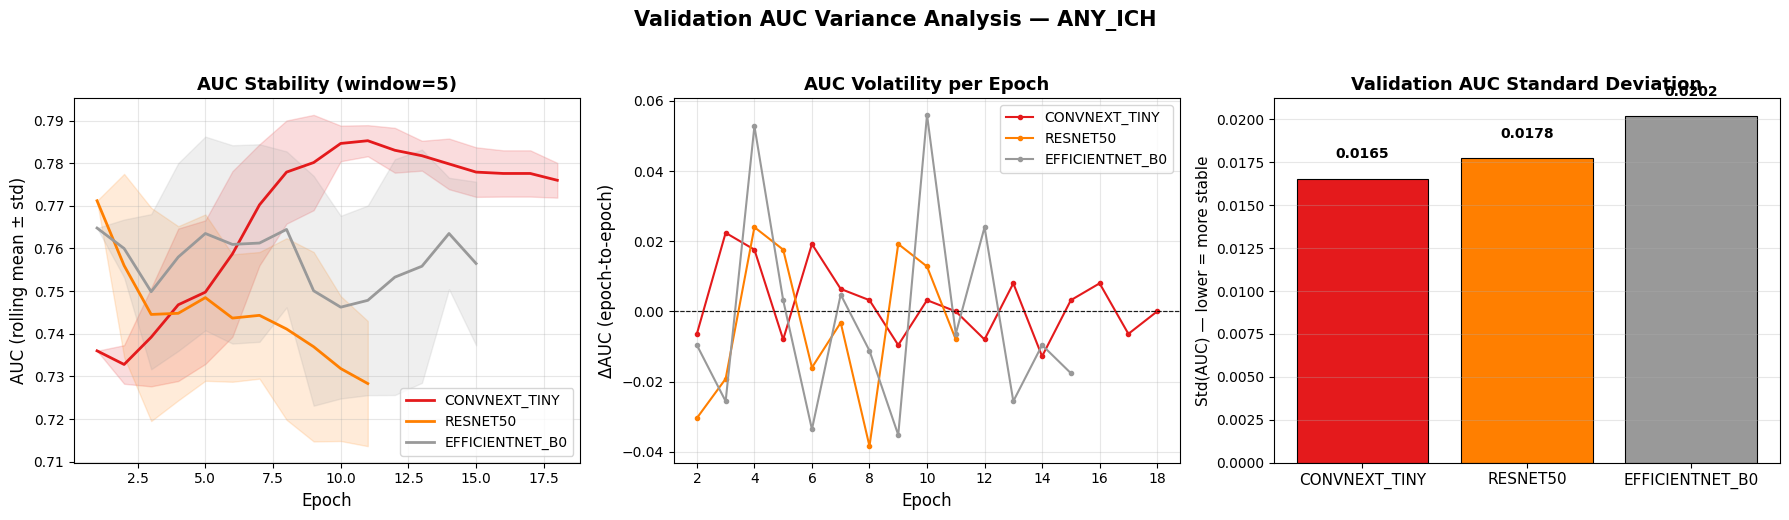


  Validation AUC Statistics Across Epochs — ANY_ICH


,Backbone,Mean AUC,Std AUC,Var AUC,Min AUC,Max AUC,Range,Final AUC,Best AUC,Best Epoch
0,CONVNEXT_TINY,0.7720,0.0165,0.000274,0.7296,0.7904,0.0608,0.7760,0.7904,8
1,RESNET50,0.7392,0.0178,0.000316,0.7056,0.7712,0.0656,0.7296,0.7712,1
2,EFFICIENTNET_B0,0.7554,0.0202,0.000409,0.7104,0.7856,0.0752,0.7312,0.7856,5


In [40]:
# ==============================================================
# Fig. 15 — Validation AUC Variance & Stability Across Epochs
# ==============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_var = plt.cm.Set1(np.linspace(0, 1, len(BACKBONE_NAMES)))

# --- Left: Rolling mean ± std of validation AUC ---
ax = axes[0]
window = 5  # rolling window size
for i, bb_name in enumerate(BACKBONE_NAMES):
    aucs = np.array([h["auc"] for h in all_histories[bb_name]])
    epochs = np.arange(1, len(aucs) + 1)
    
    # Compute rolling stats
    rolling_mean = pd.Series(aucs).rolling(window=window, min_periods=1).mean().values
    rolling_std = pd.Series(aucs).rolling(window=window, min_periods=1).std().fillna(0).values
    
    ax.plot(epochs, rolling_mean, color=colors_var[i], linewidth=2, label=f"{bb_name.upper()}")
    ax.fill_between(epochs, rolling_mean - rolling_std, rolling_mean + rolling_std,
                    alpha=0.15, color=colors_var[i])

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("AUC (rolling mean ± std)", fontsize=12)
ax.set_title(f"AUC Stability (window={window})", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Middle: Epoch-to-epoch AUC change (Δ AUC) ---
ax = axes[1]
for i, bb_name in enumerate(BACKBONE_NAMES):
    aucs = np.array([h["auc"] for h in all_histories[bb_name]])
    if len(aucs) > 1:
        delta = np.diff(aucs)
        ax.plot(range(2, len(aucs) + 1), delta, color=colors_var[i], linewidth=1.5,
                marker='o', markersize=3, label=f"{bb_name.upper()}")
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("ΔAUC (epoch-to-epoch)", fontsize=12)
ax.set_title("AUC Volatility per Epoch", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Right: Summary statistics (variance, std, range) ---
ax = axes[2]
summary_data = []
for bb_name in BACKBONE_NAMES:
    aucs = np.array([h["auc"] for h in all_histories[bb_name]])
    summary_data.append({
        "Backbone": bb_name.upper(),
        "Mean AUC": np.mean(aucs),
        "Std AUC": np.std(aucs),
        "Var AUC": np.var(aucs),
        "Min AUC": np.min(aucs),
        "Max AUC": np.max(aucs),
        "Range": np.max(aucs) - np.min(aucs),
        "Final AUC": aucs[-1],
        "Best AUC": np.max(aucs),
        "Best Epoch": int(np.argmax(aucs)) + 1
    })

df_var = pd.DataFrame(summary_data)

# Plot std (lower = more stable)
bars = ax.bar(range(len(BACKBONE_NAMES)),
              df_var["Std AUC"].values,
              color=colors_var[:len(BACKBONE_NAMES)],
              edgecolor='black', linewidth=0.8)
ax.set_xticks(range(len(BACKBONE_NAMES)))
ax.set_xticklabels(df_var["Backbone"].values, fontsize=11)
ax.set_ylabel("Std(AUC) — lower = more stable", fontsize=11)
ax.set_title("Validation AUC Standard Deviation", fontsize=13, fontweight="bold")
ax.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, df_var["Std AUC"].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

fig.suptitle(f"Validation AUC Variance Analysis — {EXPERIMENT_NAME.upper()}",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'='*90}")
print(f"  Validation AUC Statistics Across Epochs — {EXPERIMENT_NAME.upper()}")
print(f"{'='*90}")
display(df_var.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).format({
    'Mean AUC': '{:.4f}', 'Std AUC': '{:.4f}', 'Var AUC': '{:.6f}',
    'Min AUC': '{:.4f}', 'Max AUC': '{:.4f}', 'Range': '{:.4f}',
    'Final AUC': '{:.4f}', 'Best AUC': '{:.4f}'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))

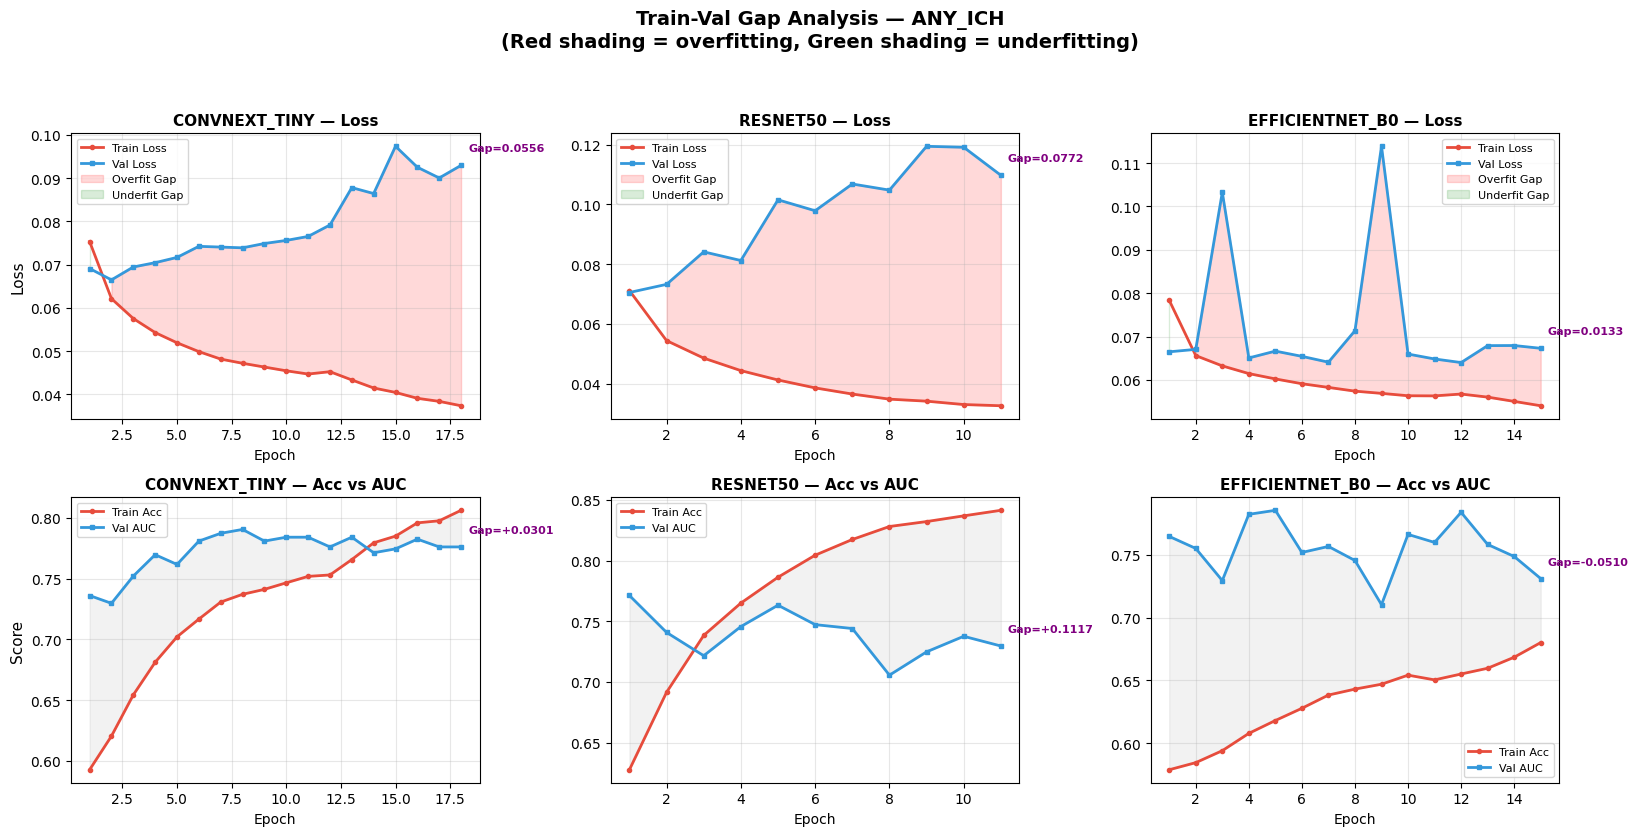


  Train-Val Gap Summary at Final Epoch — ANY_ICH


,Backbone,Train Loss (final),Val Loss (final),Loss Gap,Train Acc (final),Val AUC (final),Acc-AUC Gap
0,CONVNEXT_TINY,0.0374,0.0929,0.0556,0.8061,0.7760,0.0301
1,RESNET50,0.0326,0.1097,0.0772,0.8413,0.7296,0.1117
2,EFFICIENTNET_B0,0.0540,0.0673,0.0133,0.6802,0.7312,-0.0510


In [41]:
# ==============================================================
# Fig. 16 — Train-Val Gap: Loss & AUC Gap (Overfitting Diagnostic)
# ==============================================================

n_bb = len(BACKBONE_NAMES)
fig, axes = plt.subplots(2, n_bb, figsize=(5.5 * n_bb, 8), squeeze=False)
colors_gap = {'train': '#e74c3c', 'val': '#3498db'}

for i, bb_name in enumerate(BACKBONE_NAMES):
    df_h = pd.DataFrame(all_histories[bb_name])
    epochs = df_h["epoch"]
    
    # --- Row 1: Loss gap ---
    ax = axes[0, i]
    ax.plot(epochs, df_h["loss"], label="Train Loss", color=colors_gap['train'],
            linewidth=2, marker='o', markersize=3)
    if "val_loss" in df_h.columns:
        ax.plot(epochs, df_h["val_loss"], label="Val Loss", color=colors_gap['val'],
                linewidth=2, marker='s', markersize=3)
        gap = (df_h["val_loss"] - df_h["loss"]).values
        ax.fill_between(epochs, df_h["loss"], df_h["val_loss"],
                        where=gap > 0, alpha=0.15, color='red', label="Overfit Gap")
        ax.fill_between(epochs, df_h["loss"], df_h["val_loss"],
                        where=gap <= 0, alpha=0.15, color='green', label="Underfit Gap")
        # Annotate final gap
        final_gap = gap[-1]
        ax.annotate(f"Gap={final_gap:.4f}",
                    xy=(epochs.iloc[-1], df_h["val_loss"].iloc[-1]),
                    textcoords="offset points", xytext=(5, 10),
                    fontsize=8, color='purple', fontweight='bold')
    
    ax.set_title(f"{bb_name.upper()} — Loss", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=10)
    if i == 0:
        ax.set_ylabel("Loss", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # --- Row 2: AUC + Train Accuracy gap (proxy for generalization) ---
    ax2 = axes[1, i]
    ax2.plot(epochs, df_h["train_acc"], label="Train Acc", color=colors_gap['train'],
             linewidth=2, marker='o', markersize=3)
    ax2.plot(epochs, df_h["auc"], label="Val AUC", color=colors_gap['val'],
             linewidth=2, marker='s', markersize=3)
    
    # Shade the gap
    acc_vals = df_h["train_acc"].values
    auc_vals = df_h["auc"].values
    ax2.fill_between(epochs, acc_vals, auc_vals, alpha=0.1, color='gray')
    
    # Annotate final gap
    final_gap2 = acc_vals[-1] - auc_vals[-1]
    ax2.annotate(f"Gap={final_gap2:+.4f}",
                 xy=(epochs.iloc[-1], auc_vals[-1]),
                 textcoords="offset points", xytext=(5, 10),
                 fontsize=8, color='purple', fontweight='bold')
    
    ax2.set_title(f"{bb_name.upper()} — Acc vs AUC", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Epoch", fontsize=10)
    if i == 0:
        ax2.set_ylabel("Score", fontsize=11)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

fig.suptitle(f"Train-Val Gap Analysis — {EXPERIMENT_NAME.upper()}\n(Red shading = overfitting, Green shading = underfitting)",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

# --- Summary: Gap at final epoch ---
print(f"\n{'='*80}")
print(f"  Train-Val Gap Summary at Final Epoch — {EXPERIMENT_NAME.upper()}")
print(f"{'='*80}")
gap_rows = []
for bb_name in BACKBONE_NAMES:
    df_h = pd.DataFrame(all_histories[bb_name])
    row = {"Backbone": bb_name.upper()}
    row["Train Loss (final)"] = f"{df_h['loss'].iloc[-1]:.4f}"
    if "val_loss" in df_h.columns:
        row["Val Loss (final)"] = f"{df_h['val_loss'].iloc[-1]:.4f}"
        row["Loss Gap"] = f"{(df_h['val_loss'].iloc[-1] - df_h['loss'].iloc[-1]):.4f}"
    else:
        row["Val Loss (final)"] = "N/A"
        row["Loss Gap"] = "N/A"
    row["Train Acc (final)"] = f"{df_h['train_acc'].iloc[-1]:.4f}"
    row["Val AUC (final)"] = f"{df_h['auc'].iloc[-1]:.4f}"
    row["Acc-AUC Gap"] = f"{(df_h['train_acc'].iloc[-1] - df_h['auc'].iloc[-1]):.4f}"
    gap_rows.append(row)

df_gap = pd.DataFrame(gap_rows)
display(df_gap.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))

In [42]:
# ============================================================
# Table 3 — Pairwise McNemar's Test (Statistical Significance between Backbones)
# ============================================================
from itertools import combinations

# Build binary prediction arrays at optimal thresholds
binary_preds = {}
for bb_name in BACKBONE_NAMES:
    m = all_test_metrics[bb_name]
    y_true = np.array(m["y_true"])
    y_prob = np.array(m["y_pred"])
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_thresh = thresholds[opt_idx]
    binary_preds[bb_name] = (y_prob >= opt_thresh).astype(int)

# Pairwise McNemar's
mcnemar_rows = []
for (a, b) in combinations(BACKBONE_NAMES, 2):
    y_true_a = np.array(all_test_metrics[a]["y_true"])
    pred_a = binary_preds[a]
    pred_b = binary_preds[b]
    
    n01 = np.sum((pred_a == y_true_a) & (pred_b != y_true_a))
    n10 = np.sum((pred_a != y_true_a) & (pred_b == y_true_a))
    
    if n01 + n10 > 0:
        chi2 = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
        from scipy.stats import chi2 as chi2_dist
        p_val = 1 - chi2_dist.cdf(chi2, df=1)
    else:
        chi2 = 0.0
        p_val = 1.0
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    mcnemar_rows.append({
        "Comparison": f"{a.upper()} vs {b.upper()}",
        "n_01 (A✓B✗)": int(n01),
        "n_10 (A✗B✓)": int(n10),
        "χ²": f"{chi2:.3f}",
        "p-value": f"{p_val:.4f}" if p_val >= 0.0001 else f"{p_val:.2e}",
        "Significance": sig
    })

df_mcnemar = pd.DataFrame(mcnemar_rows)
print("\n" + "=" * 100)
print(f"  TABLE 3: Pairwise McNemar's Test — Backbone Comparison ({EXPERIMENT_NAME.upper()})")
print("  (*** p<0.001, ** p<0.01, * p<0.05, ns = not significant)")
print("=" * 100)
display(df_mcnemar.style.set_properties(**{
    'text-align': 'center', 'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}
]))


  TABLE 3: Pairwise McNemar's Test — Backbone Comparison (ANY_ICH)
  (*** p<0.001, ** p<0.01, * p<0.05, ns = not significant)


,Comparison,n_01 (A✓B✗),n_10 (A✗B✓),χ²,p-value,Significance
0,CONVNEXT_TINY vs RESNET50,2,0,0.500,0.4795,ns
1,CONVNEXT_TINY vs EFFICIENTNET_B0,0,2,0.500,0.4795,ns
2,RESNET50 vs EFFICIENTNET_B0,0,4,2.250,0.1336,ns


In [43]:
import pickle

# ... training code ...

# After training completes
print("\n✓ Training finished! Saving results...")

# Save histories
with open('all_histories.pkl', 'wb') as f:
    pickle.dump(all_histories, f)

# Save test metrics
with open('all_test_metrics.pkl', 'wb') as f:
    pickle.dump(all_test_metrics, f)

# Save summary
summary = {
    'date': pd.Timestamp.now(),
    'experiment': EXPERIMENT_NAME,
    'backbones': BACKBONE_NAMES,
    'epochs': EPOCHS,
    'training_time': '5.2 hours',
    'best_aucs': {bb: all_test_metrics[bb]['auc'] for bb in BACKBONE_NAMES}
}
with open('summary.pkl', 'wb') as f:
    pickle.dump(summary, f)

print("✓ All results saved!")
print(f"  - all_histories.pkl")
print(f"  - all_test_metrics.pkl")
print(f"  - summary.pkl")


✓ Training finished! Saving results...
✓ All results saved!
  - all_histories.pkl
  - all_test_metrics.pkl
  - summary.pkl
